<a href="https://colab.research.google.com/github/DengDuangLang111/494-algo-representations/blob/task4/week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
import glob
import os
import zipfile

drive.mount('/content/drive')
BASE = Path("/content/drive/MyDrive/494data")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import glob
import os
import zipfile

BASE = Path("/content/drive/MyDrive/494data")
BOT_IDS_PATH = BASE / "cn_bot_accounts_ids.csv"

def read_zipped_tsvs(pattern, usecols=None, dtype=None, required=True):
    files = sorted(glob.glob(str(pattern)))

    if not files:
        print(f"[WARN] No files matched: {pattern}")
        print("[DEBUG] Files currently under BASE:")
        for f in sorted(os.listdir(BASE)):
            print("   ", f)
        if required:
            raise FileNotFoundError(f"No files matched: {pattern}")
        return pd.DataFrame()

    dfs = []
    for f in files:
        print("Reading:", os.path.basename(f))
        with zipfile.ZipFile(f, "r") as z:
            inner_files = [name for name in z.namelist() if not name.endswith("/")]
            print("   inner files:", inner_files)

            tsv_files = [name for name in inner_files if name.lower().endswith(".tsv")]
            target = tsv_files[0] if tsv_files else inner_files[0]

            with z.open(target) as fp:
                df = pd.read_csv(
                    fp,
                    sep="\t",
                    low_memory=False,
                    usecols=usecols,
                    dtype=dtype
                )
                dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

notes = read_zipped_tsvs(BASE / "notes-*.zip")
status = read_zipped_tsvs(BASE / "noteStatusHistory-*.zip")
ratings = read_zipped_tsvs(BASE / "ratings-*.zip")
requests = read_zipped_tsvs(BASE / "batSignals-*.zip")
bot_ids = pd.read_csv(BOT_IDS_PATH)

print("\nLoaded shapes:")
print("notes   :", notes.shape)
print("status  :", status.shape)
print("ratings :", ratings.shape)
print("requests:", requests.shape)
print("bot_ids :", bot_ids.shape)

Reading: notes-00000 (1).zip
   inner files: ['notes-00000.tsv']


KeyboardInterrupt: 

In [3]:
print("\nnotes columns:")
print(notes.columns.tolist())

print("\nstatus columns:")
print(status.columns.tolist())

print("\nratings columns:")
print(ratings.columns.tolist())

print("\nrequests columns:")
print(requests.columns.tolist())

print("\nbot_ids columns:")
print(bot_ids.columns.tolist())


notes columns:
['noteId', 'noteAuthorParticipantId', 'createdAtMillis', 'tweetId', 'classification', 'believable', 'harmful', 'validationDifficulty', 'misleadingOther', 'misleadingFactualError', 'misleadingManipulatedMedia', 'misleadingOutdatedInformation', 'misleadingMissingImportantContext', 'misleadingUnverifiedClaimAsFact', 'misleadingSatire', 'notMisleadingOther', 'notMisleadingFactuallyCorrect', 'notMisleadingOutdatedButNotWhenWritten', 'notMisleadingClearlySatire', 'notMisleadingPersonalOpinion', 'trustworthySources', 'summary', 'isMediaNote', 'isCollaborativeNote']

status columns:
['noteId', 'noteAuthorParticipantId', 'createdAtMillis', 'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus', 'timestampMillisOfCurrentStatus', 'currentStatus', 'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus', 'timestampMillisOfStatusLock', 'lockedStatus', 'timestampMillisOfRetroLock', 'currentCoreStatus', 'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy', 'cur

In [4]:
from datetime import datetime

SAVE_DIR = BASE / "week8_cache"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

notes_path = SAVE_DIR / f"notes_{stamp}.parquet"
status_path = SAVE_DIR / f"status_{stamp}.parquet"
ratings_path = SAVE_DIR / f"ratings_{stamp}.parquet"
requests_path = SAVE_DIR / f"requests_{stamp}.parquet"
bot_ids_path = SAVE_DIR / f"bot_ids_{stamp}.parquet"

print("Saving notes...")
notes.to_parquet(notes_path, index=False, compression="snappy")

print("Saving status...")
status.to_parquet(status_path, index=False, compression="snappy")

print("Saving ratings... this may take a while")
ratings.to_parquet(ratings_path, index=False, compression="snappy")

print("Saving requests...")
requests.to_parquet(requests_path, index=False, compression="snappy")

print("Saving bot_ids...")
bot_ids.to_parquet(bot_ids_path, index=False, compression="snappy")

print("\nSaved files:")
for p in [notes_path, status_path, ratings_path, requests_path, bot_ids_path]:
    print(p)

Saving notes...
Saving status...
Saving ratings... this may take a while
Saving requests...
Saving bot_ids...

Saved files:
/content/drive/MyDrive/494data/week8_cache/notes_20260312_093415.parquet
/content/drive/MyDrive/494data/week8_cache/status_20260312_093415.parquet
/content/drive/MyDrive/494data/week8_cache/ratings_20260312_093415.parquet
/content/drive/MyDrive/494data/week8_cache/requests_20260312_093415.parquet
/content/drive/MyDrive/494data/week8_cache/bot_ids_20260312_093415.parquet


In [6]:
from pathlib import Path
import shutil

BASE = Path("/content/drive/MyDrive/494data")
CACHE = BASE / "week8_cache"
STAMP = "20260312_093415"

src_map = {
    CACHE / f"notes_{STAMP}.parquet": CACHE / "notes_latest.parquet",
    CACHE / f"status_{STAMP}.parquet": CACHE / "status_latest.parquet",
    CACHE / f"ratings_{STAMP}.parquet": CACHE / "ratings_latest.parquet",
    CACHE / f"requests_{STAMP}.parquet": CACHE / "requests_latest.parquet",
    CACHE / f"bot_ids_{STAMP}.parquet": CACHE / "bot_ids_latest.parquet",
}

for src, dst in src_map.items():
    print("copy:", src.name, "->", dst.name)
    shutil.copy2(src, dst)

print("done")

copy: notes_20260312_093415.parquet -> notes_latest.parquet
copy: status_20260312_093415.parquet -> status_latest.parquet
copy: ratings_20260312_093415.parquet -> ratings_latest.parquet
copy: requests_20260312_093415.parquet -> requests_latest.parquet
copy: bot_ids_20260312_093415.parquet -> bot_ids_latest.parquet
done


In [4]:
for p in sorted((BASE / "week8_cache").glob("*latest.parquet")):
    print(p.name, p.stat().st_size / 1024 / 1024, "MB")

bot_ids_latest.parquet 0.009832382202148438 MB
notes_latest.parquet 497.8694534301758 MB
ratings_latest.parquet 14235.794489860535 MB
requests_latest.parquet 9.420445442199707 MB
status_latest.parquet 190.94398307800293 MB


In [4]:
notes = pd.read_parquet(BASE / "week8_cache/notes_latest.parquet")
status = pd.read_parquet(BASE / "week8_cache/status_latest.parquet")
requests = pd.read_parquet(BASE / "week8_cache/requests_latest.parquet")
bot_ids = pd.read_parquet(BASE / "week8_cache/bot_ids_latest.parquet")
ratings = pd.read_parquet(BASE / "week8_cache/ratings_latest.parquet")

In [5]:
BASE = Path("/content/drive/MyDrive/494data")
CACHE = BASE / "week8_cache"
CACHE.mkdir(exist_ok=True)

# 只取 Step 2 需要的列
step2_notes = notes[
    [
        "noteId",
        "tweetId",
        "noteAuthorParticipantId",
        "createdAtMillis",
        "classification",
        "summary",
        "isMediaNote",
        "isCollaborativeNote"
    ]
].copy()

# 类型统一
step2_notes["noteId"] = step2_notes["noteId"].astype(str)
step2_notes["tweetId"] = step2_notes["tweetId"].astype(str)
step2_notes["noteAuthorParticipantId"] = step2_notes["noteAuthorParticipantId"].astype(str)

bot_ids_small = bot_ids[["participantId"]].copy()
bot_ids_small["participantId"] = bot_ids_small["participantId"].astype(str)
bot_id_set = set(bot_ids_small["participantId"])

# 1. 至少有一条 collaborative note 的 tweet
target_tweet_ids = step2_notes.loc[
    step2_notes["isCollaborativeNote"] == 1,
    "tweetId"
].unique()

print("target tweet count:", len(target_tweet_ids))

# 2. 保留这些 tweet 上所有 notes
step2_subset = step2_notes.loc[
    step2_notes["tweetId"].isin(target_tweet_ids)
].copy()

# 3. 分类
step2_subset["note_type"] = np.where(
    step2_subset["isCollaborativeNote"] == 1,
    "collab",
    np.where(
        step2_subset["noteAuthorParticipantId"].isin(bot_id_set),
        "bot",
        "human"
    )
)

print("step2_subset shape:", step2_subset.shape)
print(step2_subset["note_type"].value_counts(dropna=False))
display(step2_subset.head())

target tweet count: 4589
step2_subset shape: (12421, 9)
note_type
collab    10878
human      1170
bot         373
Name: count, dtype: int64


,noteId,tweetId,noteAuthorParticipantId,createdAtMillis,classification,summary,isMediaNote,isCollaborativeNote,note_type
4349,2027666887375573258,2027530195905736916,DAFF63AF82C670F0C5418BB0A13909385E1317F0C48F40...,1772268432837,MISINFORMED_OR_POTENTIALLY_MISLEADING,This is not Anthropic's headquarters. The AI c...,0,0,human
6120,2021162208172880365,2021002549491302715,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1770717596464,MISINFORMED_OR_POTENTIALLY_MISLEADING,Congress shall make no law respecting an estab...,0,0,human
6131,2025686681626796278,2025478658622976132,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1771796314995,MISINFORMED_OR_POTENTIALLY_MISLEADING,Bill Gates was not &quot;indicted&quot; in the...,1,0,human
6159,2030972730938368293,2030773103563825387,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1773056607361,MISINFORMED_OR_POTENTIALLY_MISLEADING,The number came from a website listing reports...,1,0,human
8770,2025525278265459110,2025127875544817894,27005C91F2262A33F14511CD38A75AFFA57D1E072AEE7B...,1771757833435,MISINFORMED_OR_POTENTIALLY_MISLEADING,Poster later admitted that it may not have bee...,0,0,human


In [6]:
# note 数量 by type
note_counts_by_type = (
    step2_subset.groupby("note_type")
    .size()
    .reset_index(name="note_count")
    .sort_values("note_count", ascending=False)
)

# tweet 数量
tweet_count = step2_subset["tweetId"].nunique()

# 每个 tweet 上有多少 note
notes_per_tweet = (
    step2_subset.groupby("tweetId")
    .size()
    .reset_index(name="notes_per_tweet")
)

# tweet 上出现了哪些类型
tweet_type_presence = (
    step2_subset.assign(flag=1)
    .pivot_table(
        index="tweetId",
        columns="note_type",
        values="flag",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

for col in ["collab", "bot", "human"]:
    if col not in tweet_type_presence.columns:
        tweet_type_presence[col] = 0

tweet_type_presence["type_combo"] = (
    "collab=" + tweet_type_presence["collab"].astype(str) +
    "_bot=" + tweet_type_presence["bot"].astype(str) +
    "_human=" + tweet_type_presence["human"].astype(str)
)

tweet_combo_counts = (
    tweet_type_presence.groupby("type_combo")
    .size()
    .reset_index(name="tweet_count")
    .sort_values("tweet_count", ascending=False)
)

basic_summary = pd.DataFrame({
    "metric": [
        "tweets_with_at_least_one_collab_note",
        "total_notes_in_step2_subset",
        "avg_notes_per_tweet",
        "median_notes_per_tweet",
        "max_notes_per_tweet"
    ],
    "value": [
        tweet_count,
        step2_subset["noteId"].nunique(),
        notes_per_tweet["notes_per_tweet"].mean(),
        notes_per_tweet["notes_per_tweet"].median(),
        notes_per_tweet["notes_per_tweet"].max()
    ]
})

display(note_counts_by_type)
display(basic_summary)
display(tweet_combo_counts.head(20))

,note_type,note_count
1,collab,10878
2,human,1170
0,bot,373


,metric,value
0,tweets_with_at_least_one_collab_note,4589.00000
1,total_notes_in_step2_subset,12421.00000
2,avg_notes_per_tweet,2.70669
3,median_notes_per_tweet,1.00000
4,max_notes_per_tweet,112.00000


,type_combo,tweet_count
0,collab=1_bot=0_human=0,3667
1,collab=1_bot=0_human=1,612
2,collab=1_bot=1_human=0,214
3,collab=1_bot=1_human=1,96


In [7]:
OUT = CACHE / "step2_outputs"
OUT.mkdir(exist_ok=True)

step2_subset.to_parquet(OUT / "step2_subset_notes.parquet", index=False)
note_counts_by_type.to_csv(OUT / "step2_note_counts_by_type.csv", index=False)
basic_summary.to_csv(OUT / "step2_basic_summary.csv", index=False)
notes_per_tweet.to_csv(OUT / "step2_notes_per_tweet.csv", index=False)
tweet_combo_counts.to_csv(OUT / "step2_tweet_type_combos.csv", index=False)

print("saved to:", OUT)

saved to: /content/drive/MyDrive/494data/week8_cache/step2_outputs


In [8]:
tweet_presence_summary = pd.DataFrame({
    "metric": [
        "tweets_with_collab",
        "tweets_with_human",
        "tweets_with_bot",
        "tweets_with_collab_and_human",
        "tweets_with_collab_and_bot",
        "tweets_with_all_three"
    ],
    "value": [
        len(tweet_type_presence[tweet_type_presence["collab"] == 1]),
        len(tweet_type_presence[tweet_type_presence["human"] == 1]),
        len(tweet_type_presence[tweet_type_presence["bot"] == 1]),
        len(tweet_type_presence[(tweet_type_presence["collab"] == 1) & (tweet_type_presence["human"] == 1)]),
        len(tweet_type_presence[(tweet_type_presence["collab"] == 1) & (tweet_type_presence["bot"] == 1)]),
        len(tweet_type_presence[(tweet_type_presence["collab"] == 1) & (tweet_type_presence["human"] == 1) & (tweet_type_presence["bot"] == 1)]),
    ]
})

display(tweet_presence_summary)

,metric,value
0,tweets_with_collab,4589
1,tweets_with_human,708
2,tweets_with_bot,310
3,tweets_with_collab_and_human,708
4,tweets_with_collab_and_bot,310
5,tweets_with_all_three,96


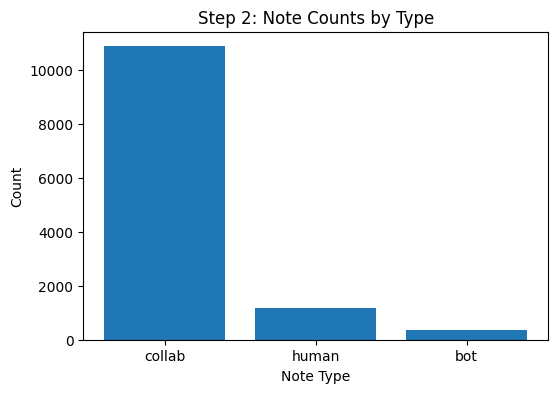

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(note_counts_by_type["note_type"], note_counts_by_type["note_count"])
plt.title("Step 2: Note Counts by Type")
plt.xlabel("Note Type")
plt.ylabel("Count")
plt.show()

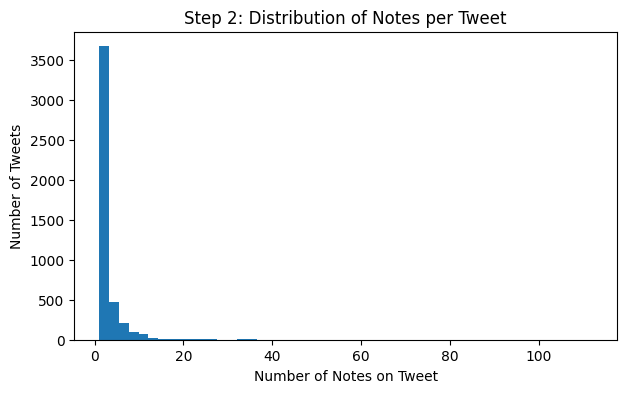

In [10]:
plt.figure(figsize=(7,4))
plt.hist(notes_per_tweet["notes_per_tweet"], bins=50)
plt.title("Step 2: Distribution of Notes per Tweet")
plt.xlabel("Number of Notes on Tweet")
plt.ylabel("Number of Tweets")
plt.show()

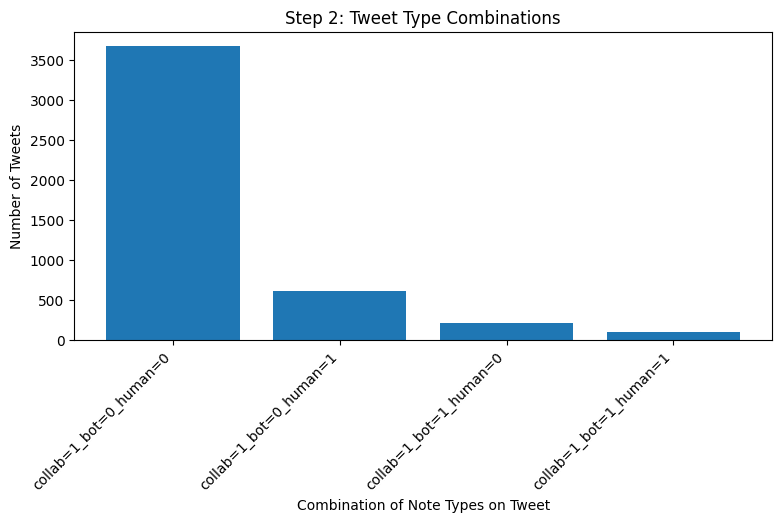

In [11]:
combo_plot = tweet_combo_counts.copy()

plt.figure(figsize=(9,4))
plt.bar(combo_plot["type_combo"], combo_plot["tweet_count"])
plt.title("Step 2: Tweet Type Combinations")
plt.xlabel("Combination of Note Types on Tweet")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45, ha="right")
plt.show()

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import gc

BASE = Path("/content/drive/MyDrive/494data")
CACHE = BASE / "week8_cache"
STEP2_OUT = CACHE / "step2_outputs"

# 如果 step2_subset 不在内存里，就读回来
try:
    step2_subset.shape
except NameError:
    step2_subset = pd.read_parquet(STEP2_OUT / "step2_subset_notes.parquet")

# 统一类型，避免 merge / isin 出问题
step2_subset["noteId"] = step2_subset["noteId"].astype(str)
step2_subset["tweetId"] = step2_subset["tweetId"].astype(str)

status["noteId"] = status["noteId"].astype(str)
ratings["noteId"] = ratings["noteId"].astype(str)
ratings["ratedOnTweetId"] = ratings["ratedOnTweetId"].astype(str)

target_note_ids = set(step2_subset["noteId"])
target_tweet_ids = set(step2_subset["tweetId"])

print("step2_subset:", step2_subset.shape)
print("unique target notes:", len(target_note_ids))
print("unique target tweets:", len(target_tweet_ids))

step2_subset: (12421, 9)
unique target notes: 12421
unique target tweets: 4589


In [13]:
subset_status = status.loc[
    status["noteId"].isin(target_note_ids),
    [
        "noteId",
        "createdAtMillis",
        "timestampMillisOfFirstNonNMRStatus",
        "firstNonNMRStatus",
        "currentStatus"
    ]
].copy()

subset_ratings = ratings.loc[
    ratings["noteId"].isin(target_note_ids),
    [
        "noteId",
        "createdAtMillis",
        "helpful",
        "notHelpful",
        "helpfulnessLevel",
        "ratedOnTweetId",
        "suggestion"
    ]
].copy()

print("subset_status:", subset_status.shape)
print("subset_ratings:", subset_ratings.shape)

subset_status.to_parquet(CACHE / "subset_status.parquet", index=False)
subset_ratings.to_parquet(CACHE / "subset_ratings.parquet", index=False)

print("saved subset_status.parquet and subset_ratings.parquet")

subset_status: (10080, 5)
subset_ratings: (449720, 7)
saved subset_status.parquet and subset_ratings.parquet


In [14]:
def normalize_status(x):
    if pd.isna(x):
        return np.nan
    s = str(x).upper().strip()
    if ("NEEDS_MORE_RATINGS" in s) or (s == "NMR"):
        return "NMR"
    if ("CURRENTLY_RATED_HELPFUL" in s) or (s == "CRH"):
        return "CRH"
    if ("CURRENTLY_RATED_NOT_HELPFUL" in s) or (s == "CRNH"):
        return "CRNH"
    return s

subset_status["currentStatus_std"] = subset_status["currentStatus"].map(normalize_status)
subset_status["firstNonNMRStatus_std"] = subset_status["firstNonNMRStatus"].map(normalize_status)

print(subset_status["currentStatus_std"].value_counts(dropna=False))
print(subset_status["firstNonNMRStatus_std"].value_counts(dropna=False))

currentStatus_std
NMR     9559
CRH      325
CRNH     196
Name: count, dtype: int64
firstNonNMRStatus_std
NaN     9375
CRH      387
CRNH     318
Name: count, dtype: int64


In [15]:
analysis_notes = step2_subset.merge(
    subset_status[
        [
            "noteId",
            "createdAtMillis",
            "timestampMillisOfFirstNonNMRStatus",
            "firstNonNMRStatus",
            "firstNonNMRStatus_std",
            "currentStatus",
            "currentStatus_std"
        ]
    ],
    on="noteId",
    how="left",
    suffixes=("", "_status")
)

analysis_notes["time_to_non_nmr_hours"] = (
    analysis_notes["timestampMillisOfFirstNonNMRStatus"] - analysis_notes["createdAtMillis"]
) / (1000 * 60 * 60)

# 防止出现异常负值
analysis_notes.loc[
    analysis_notes["time_to_non_nmr_hours"] < 0,
    "time_to_non_nmr_hours"
] = np.nan

print("analysis_notes:", analysis_notes.shape)
display(analysis_notes.head())

analysis_notes: (12421, 16)


,noteId,tweetId,noteAuthorParticipantId,createdAtMillis,classification,summary,isMediaNote,isCollaborativeNote,note_type,createdAtMillis_status,timestampMillisOfFirstNonNMRStatus,firstNonNMRStatus,firstNonNMRStatus_std,currentStatus,currentStatus_std,time_to_non_nmr_hours
0,2027666887375573258,2027530195905736916,DAFF63AF82C670F0C5418BB0A13909385E1317F0C48F40...,1772268432837,MISINFORMED_OR_POTENTIALLY_MISLEADING,This is not Anthropic's headquarters. The AI c...,0,0,human,1.772268e+12,1.772304e+12,CURRENTLY_RATED_HELPFUL,CRH,NEEDS_MORE_RATINGS,NMR,9.878939
1,2021162208172880365,2021002549491302715,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1770717596464,MISINFORMED_OR_POTENTIALLY_MISLEADING,Congress shall make no law respecting an estab...,0,0,human,1.770718e+12,NaN,None,NaN,NEEDS_MORE_RATINGS,NMR,NaN
2,2025686681626796278,2025478658622976132,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1771796314995,MISINFORMED_OR_POTENTIALLY_MISLEADING,Bill Gates was not &quot;indicted&quot; in the...,1,0,human,1.771796e+12,NaN,None,NaN,NEEDS_MORE_RATINGS,NMR,NaN
3,2030972730938368293,2030773103563825387,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1773056607361,MISINFORMED_OR_POTENTIALLY_MISLEADING,The number came from a website listing reports...,1,0,human,1.773057e+12,NaN,None,NaN,NEEDS_MORE_RATINGS,NMR,NaN
4,2025525278265459110,2025127875544817894,27005C91F2262A33F14511CD38A75AFFA57D1E072AEE7B...,1771757833435,MISINFORMED_OR_POTENTIALLY_MISLEADING,Poster later admitted that it may not have bee...,0,0,human,1.771758e+12,NaN,None,NaN,NEEDS_MORE_RATINGS,NMR,NaN


In [17]:
print("subset_ratings shape:", subset_ratings.shape)

print("\nhelpful value counts:")
print(subset_ratings["helpful"].value_counts(dropna=False).head(20))

print("\nnotHelpful value counts:")
print(subset_ratings["notHelpful"].value_counts(dropna=False).head(20))

print("\nhelpfulnessLevel value counts:")
print(subset_ratings["helpfulnessLevel"].value_counts(dropna=False).head(20))

display(
    subset_ratings[
        ["noteId", "helpful", "notHelpful", "helpfulnessLevel", "suggestion"]
    ].head(20)
)

subset_ratings shape: (449720, 7)

helpful value counts:
helpful
0    449720
Name: count, dtype: int64

notHelpful value counts:
notHelpful
0    449720
Name: count, dtype: int64

helpfulnessLevel value counts:
helpfulnessLevel
HELPFUL             270577
NOT_HELPFUL         167877
SOMEWHAT_HELPFUL     11266
Name: count, dtype: int64


,noteId,helpful,notHelpful,helpfulnessLevel,suggestion
2073578,1974695261890060342,0,0,NOT_HELPFUL,None
2073579,1974695261890060342,0,0,HELPFUL,None
2073580,1974695261890060342,0,0,HELPFUL,None
2073581,1974695261890060342,0,0,HELPFUL,None
2073582,1974695261890060342,0,0,HELPFUL,None
2073583,1974695261890060342,0,0,HELPFUL,None
2073584,1974695261890060342,0,0,HELPFUL,None
2073585,1974695261890060342,0,0,HELPFUL,None
2073586,1974695261890060342,0,0,NOT_HELPFUL,None
2073587,1974695261890060342,0,0,HELPFUL,None


In [18]:
ratings_with_type = subset_ratings.merge(
    step2_subset[["noteId", "note_type"]],
    on="noteId",
    how="left"
)

ratings_with_type["helpfulnessLevel_clean"] = (
    ratings_with_type["helpfulnessLevel"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# 主定义：只有 HELPFUL 算 helpful
ratings_with_type["is_helpful_strict"] = (
    ratings_with_type["helpfulnessLevel_clean"] == "HELPFUL"
).astype(int)

rating_level_helpful = (
    ratings_with_type.groupby("note_type")["is_helpful_strict"]
    .mean()
    .mul(100)
    .reset_index(name="helpful_pct_rating_level")
    .sort_values("helpful_pct_rating_level", ascending=False)
)

print("rating_level_helpful")
display(rating_level_helpful)

rating_level_helpful


,note_type,helpful_pct_rating_level
0,bot,69.540041
2,human,62.551161
1,collab,52.823603


In [19]:
note_level_helpful = (
    ratings_with_type.groupby(["noteId", "note_type"])["is_helpful_strict"]
    .mean()
    .reset_index(name="helpful_pct_note")
)

note_level_helpful_summary = (
    note_level_helpful.groupby("note_type")["helpful_pct_note"]
    .mean()
    .mul(100)
    .reset_index(name="helpful_pct_note_level_avg")
    .sort_values("helpful_pct_note_level_avg", ascending=False)
)

print("note_level_helpful_summary")
display(note_level_helpful_summary)

note_level_helpful_summary


,note_type,helpful_pct_note_level_avg
0,bot,68.493590
2,human,63.622994
1,collab,46.693047


In [20]:
ratings_with_type["is_helpful_or_somewhat"] = (
    ratings_with_type["helpfulnessLevel_clean"].isin(["HELPFUL", "SOMEWHAT_HELPFUL"])
).astype(int)

rating_level_helpful_broad = (
    ratings_with_type.groupby("note_type")["is_helpful_or_somewhat"]
    .mean()
    .mul(100)
    .reset_index(name="helpful_or_somewhat_pct")
    .sort_values("helpful_or_somewhat_pct", ascending=False)
)

print("rating_level_helpful_broad")
display(rating_level_helpful_broad)

rating_level_helpful_broad


,note_type,helpful_or_somewhat_pct
0,bot,71.540041
2,human,64.647334
1,collab,56.377367


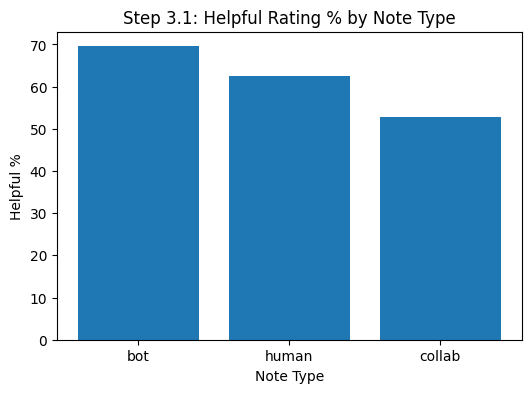

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(
    rating_level_helpful["note_type"],
    rating_level_helpful["helpful_pct_rating_level"]
)
plt.title("Step 3.1: Helpful Rating % by Note Type")
plt.xlabel("Note Type")
plt.ylabel("Helpful %")
plt.show()

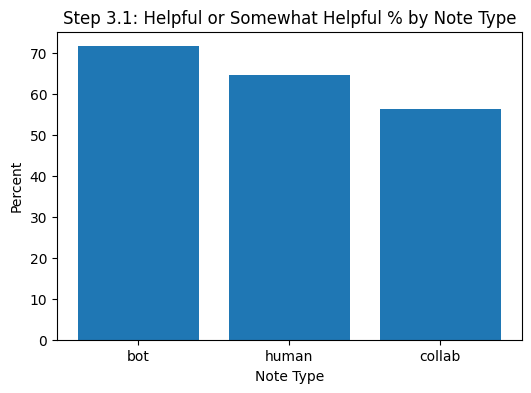

In [22]:
plt.figure(figsize=(6,4))
plt.bar(
    rating_level_helpful_broad["note_type"],
    rating_level_helpful_broad["helpful_or_somewhat_pct"]
)
plt.title("Step 3.1: Helpful or Somewhat Helpful % by Note Type")
plt.xlabel("Note Type")
plt.ylabel("Percent")
plt.show()

In [23]:
status_distribution = (
    analysis_notes.groupby(["note_type", "currentStatus_std"])
    .size()
    .reset_index(name="count")
)

status_distribution["pct_within_type"] = (
    status_distribution["count"] /
    status_distribution.groupby("note_type")["count"].transform("sum") * 100
)

status_distribution = status_distribution.sort_values(
    ["note_type", "currentStatus_std"]
)

display(status_distribution)

,note_type,currentStatus_std,count,pct_within_type
0,bot,CRH,67,18.611111
1,bot,CRNH,12,3.333333
2,bot,NMR,281,78.055556
3,collab,CRH,107,1.247668
4,collab,CRNH,115,1.340951
5,collab,NMR,8354,97.411381
6,human,CRH,151,13.199301
7,human,CRNH,69,6.031469
8,human,NMR,924,80.769231


In [24]:
time_to_non_nmr_summary = (
    analysis_notes.loc[analysis_notes["firstNonNMRStatus_std"].notna()]
    .groupby("note_type")["time_to_non_nmr_hours"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .rename(columns={
        "count": "n_notes_reached_non_nmr",
        "mean": "avg_hours_to_non_nmr",
        "median": "median_hours_to_non_nmr"
    })
)

display(time_to_non_nmr_summary)

,note_type,n_notes_reached_non_nmr,avg_hours_to_non_nmr,median_hours_to_non_nmr
0,bot,92,23.582706,5.225024
1,collab,328,18.366430,5.679383
2,human,285,21.810722,4.700100


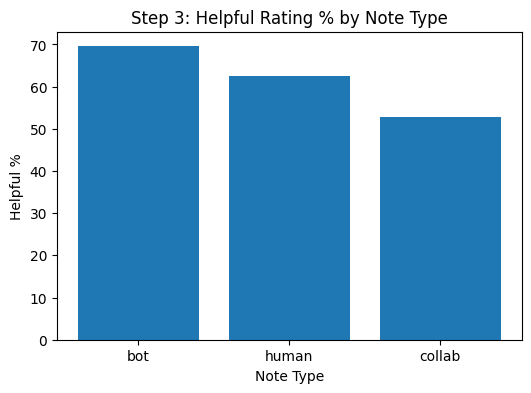

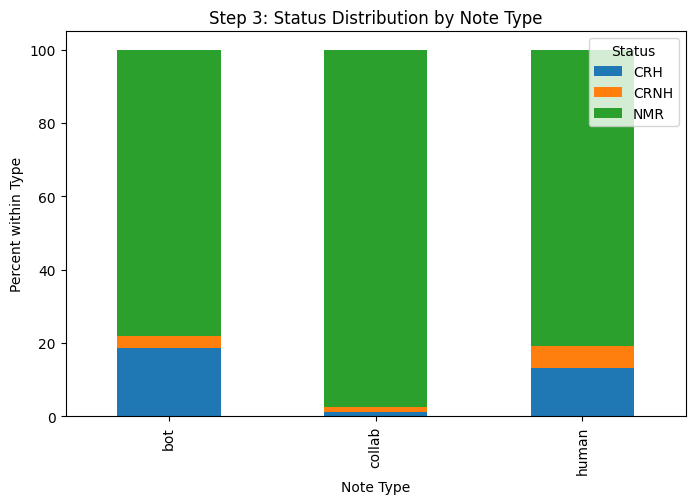

/tmp/ipykernel_14595/1207451082.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


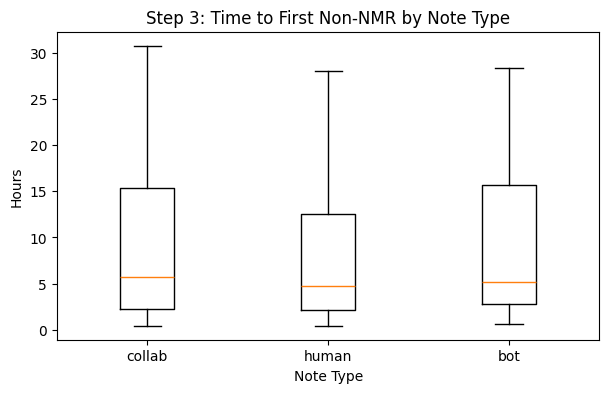

In [25]:
import matplotlib.pyplot as plt

# 1. helpful %
plt.figure(figsize=(6,4))
plt.bar(
    rating_level_helpful["note_type"],
    rating_level_helpful["helpful_pct_rating_level"]
)
plt.title("Step 3: Helpful Rating % by Note Type")
plt.xlabel("Note Type")
plt.ylabel("Helpful %")
plt.show()

# 2. status distribution
status_pivot = status_distribution.pivot(
    index="note_type",
    columns="currentStatus_std",
    values="pct_within_type"
).fillna(0)

status_pivot.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Step 3: Status Distribution by Note Type")
plt.xlabel("Note Type")
plt.ylabel("Percent within Type")
plt.legend(title="Status")
plt.show()

# 3. time to non-NMR
time_plot_df = analysis_notes.loc[
    analysis_notes["time_to_non_nmr_hours"].notna(),
    ["note_type", "time_to_non_nmr_hours"]
]

labels = []
data = []
for t in ["collab", "human", "bot"]:
    vals = time_plot_df.loc[
        time_plot_df["note_type"] == t,
        "time_to_non_nmr_hours"
    ]
    if len(vals) > 0:
        labels.append(t)
        data.append(vals)

plt.figure(figsize=(7,4))
plt.boxplot(data, labels=labels, showfliers=False)
plt.title("Step 3: Time to First Non-NMR by Note Type")
plt.xlabel("Note Type")
plt.ylabel("Hours")
plt.show()

In [26]:
status_missing_summary = (
    analysis_notes.groupby("note_type")["currentStatus_std"]
    .apply(lambda s: s.isna().sum())
    .reset_index(name="missing_current_status")
)

display(status_missing_summary)

,note_type,missing_current_status
0,bot,13
1,collab,2302
2,human,26


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("/content/drive/MyDrive/494data")
CACHE = BASE / "week8_cache"
STEP4_OUT = CACHE / "step4_outputs"
STEP4_OUT.mkdir(exist_ok=True)

# 如果 analysis_notes 不在内存里，就读回来
try:
    analysis_notes.shape
except NameError:
    analysis_notes = pd.read_parquet(CACHE / "step3_outputs/analysis_notes.parquet")

# 如果 subset_ratings 不在内存里，就读回来
try:
    subset_ratings.shape
except NameError:
    subset_ratings = pd.read_parquet(CACHE / "step3_outputs/subset_ratings.parquet")

# 统一类型
analysis_notes["noteId"] = analysis_notes["noteId"].astype(str)
analysis_notes["tweetId"] = analysis_notes["tweetId"].astype(str)

subset_ratings["noteId"] = subset_ratings["noteId"].astype(str)
subset_ratings["ratedOnTweetId"] = subset_ratings["ratedOnTweetId"].astype(str)

# 用 helpfulnessLevel 重新做 rating-level helpful 标记
subset_ratings["helpfulnessLevel_clean"] = (
    subset_ratings["helpfulnessLevel"].astype(str).str.strip().str.upper()
)

subset_ratings["is_helpful_strict"] = (
    subset_ratings["helpfulnessLevel_clean"] == "HELPFUL"
).astype(int)

subset_ratings["is_helpful_or_somewhat"] = (
    subset_ratings["helpfulnessLevel_clean"].isin(["HELPFUL", "SOMEWHAT_HELPFUL"])
).astype(int)

# 聚合到 note-level helpfulness
note_helpfulness = (
    subset_ratings.groupby("noteId")
    .agg(
        helpful_pct_strict=("is_helpful_strict", "mean"),
        helpful_or_somewhat_pct=("is_helpful_or_somewhat", "mean"),
        n_ratings=("noteId", "size")
    )
    .reset_index()
)

analysis_notes = analysis_notes.merge(
    note_helpfulness,
    on="noteId",
    how="left"
)

# request counts
request_counts = (
    requests.groupby("tweetId")
    .size()
    .reset_index(name="request_count")
)
request_counts["tweetId"] = request_counts["tweetId"].astype(str)

analysis_notes = analysis_notes.merge(
    request_counts,
    on="tweetId",
    how="left"
)

analysis_notes["request_count"] = analysis_notes["request_count"].fillna(0)

# 一些额外特征
analysis_notes["summary_len"] = analysis_notes["summary"].fillna("").astype(str).str.len()
analysis_notes["is_crh"] = (analysis_notes["currentStatus_std"] == "CRH").astype(int)
analysis_notes["is_crnh"] = (analysis_notes["currentStatus_std"] == "CRNH").astype(int)
analysis_notes["is_nmr"] = (analysis_notes["currentStatus_std"] == "NMR").astype(int)

print(analysis_notes.shape)
display(analysis_notes.head())

(12421, 24)


,noteId,tweetId,noteAuthorParticipantId,createdAtMillis,classification,summary,isMediaNote,isCollaborativeNote,note_type,createdAtMillis_status,...,currentStatus_std,time_to_non_nmr_hours,helpful_pct_strict,helpful_or_somewhat_pct,n_ratings,request_count,summary_len,is_crh,is_crnh,is_nmr
0,2027666887375573258,2027530195905736916,DAFF63AF82C670F0C5418BB0A13909385E1317F0C48F40...,1772268432837,MISINFORMED_OR_POTENTIALLY_MISLEADING,This is not Anthropic's headquarters. The AI c...,0,0,human,1.772268e+12,...,NMR,9.878939,0.836364,0.854545,55.0,1.0,452,0,0,1
1,2021162208172880365,2021002549491302715,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1770717596464,MISINFORMED_OR_POTENTIALLY_MISLEADING,Congress shall make no law respecting an estab...,0,0,human,1.770718e+12,...,NMR,NaN,0.337449,0.341564,486.0,1.0,335,0,0,1
2,2025686681626796278,2025478658622976132,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1771796314995,MISINFORMED_OR_POTENTIALLY_MISLEADING,Bill Gates was not &quot;indicted&quot; in the...,1,0,human,1.771796e+12,...,NMR,NaN,0.714286,0.795918,49.0,1.0,419,0,0,1
3,2030972730938368293,2030773103563825387,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1773056607361,MISINFORMED_OR_POTENTIALLY_MISLEADING,The number came from a website listing reports...,1,0,human,1.773057e+12,...,NMR,NaN,NaN,NaN,NaN,0.0,428,0,0,1
4,2025525278265459110,2025127875544817894,27005C91F2262A33F14511CD38A75AFFA57D1E072AEE7B...,1771757833435,MISINFORMED_OR_POTENTIALLY_MISLEADING,Poster later admitted that it may not have bee...,0,0,human,1.771758e+12,...,NMR,NaN,0.807692,0.811355,546.0,1.0,131,0,0,1


In [29]:
tweet_type_summary = (
    analysis_notes.groupby(["tweetId", "note_type"])
    .agg(
        n_notes=("noteId", "nunique"),
        crh_share=("is_crh", "mean"),
        crnh_share=("is_crnh", "mean"),
        nmr_share=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean"),
        avg_helpful_or_somewhat_pct=("helpful_or_somewhat_pct", "mean"),
        avg_n_ratings=("n_ratings", "mean"),
        avg_time_to_non_nmr=("time_to_non_nmr_hours", "mean")
    )
    .reset_index()
)

display(tweet_type_summary.head())

,tweetId,note_type,n_notes,crh_share,crnh_share,nmr_share,avg_helpful_pct,avg_helpful_or_somewhat_pct,avg_n_ratings,avg_time_to_non_nmr
0,-1,collab,8,0.0,0.0,0.125,0.571429,0.571429,3.428571,NaN
1,1300931249947672576,collab,1,0.0,0.0,1.000,1.000000,1.000000,2.000000,NaN
2,1496720501472780291,collab,1,0.0,0.0,1.000,1.000000,1.000000,16.000000,NaN
3,1496720501472780291,human,1,0.0,0.0,1.000,0.875000,0.937500,16.000000,NaN
4,1644068292389228550,collab,1,0.0,0.0,1.000,1.000000,1.000000,2.000000,NaN


In [30]:
collab_human = tweet_type_summary.pivot(
    index="tweetId",
    columns="note_type",
    values=[
        "crh_share",
        "crnh_share",
        "nmr_share",
        "avg_helpful_pct",
        "avg_helpful_or_somewhat_pct",
        "avg_n_ratings",
        "avg_time_to_non_nmr"
    ]
)

# 只保留同时有 collab 和 human 的 tweet
collab_human = collab_human.dropna(
    subset=[
        ("crh_share", "collab"),
        ("crh_share", "human")
    ]
).copy()

# 展平成普通列名
collab_human.columns = [f"{a}_{b}" for a, b in collab_human.columns]
collab_human = collab_human.reset_index()

# 差值
collab_human["diff_crh"] = collab_human["crh_share_collab"] - collab_human["crh_share_human"]
collab_human["diff_helpful"] = collab_human["avg_helpful_pct_collab"] - collab_human["avg_helpful_pct_human"]
collab_human["diff_nmr"] = collab_human["nmr_share_collab"] - collab_human["nmr_share_human"]

print("same-post collab vs human tweets:", len(collab_human))
display(collab_human.head())

print("mean diff_crh:", collab_human["diff_crh"].mean())
print("median diff_crh:", collab_human["diff_crh"].median())
print("mean diff_helpful:", collab_human["diff_helpful"].mean())
print("median diff_helpful:", collab_human["diff_helpful"].median())
print("mean diff_nmr:", collab_human["diff_nmr"].mean())

same-post collab vs human tweets: 708


,tweetId,crh_share_bot,crh_share_collab,crh_share_human,crnh_share_bot,crnh_share_collab,crnh_share_human,nmr_share_bot,nmr_share_collab,nmr_share_human,...,avg_helpful_or_somewhat_pct_human,avg_n_ratings_bot,avg_n_ratings_collab,avg_n_ratings_human,avg_time_to_non_nmr_bot,avg_time_to_non_nmr_collab,avg_time_to_non_nmr_human,diff_crh,diff_helpful,diff_nmr
0,1496720501472780291,NaN,0.0,0.0,NaN,0.0,0.000000,NaN,1.0,1.000000,...,0.937500,NaN,16.0,16.0,NaN,NaN,NaN,0.0,0.125000,0.000000
1,1707716388603781398,NaN,0.0,0.0,NaN,0.0,0.333333,NaN,1.0,0.666667,...,0.377448,NaN,4.0,555.0,NaN,NaN,4.898211,0.0,0.175053,0.333333
2,1770527552970293526,NaN,0.0,0.0,NaN,0.0,0.000000,NaN,0.0,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,310.106180,0.0,NaN,-1.000000
3,1776292066458214882,NaN,0.0,0.0,NaN,0.0,0.000000,NaN,1.0,1.000000,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000
4,1783830499317960758,NaN,0.0,0.0,NaN,0.0,0.000000,NaN,1.0,1.000000,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000


mean diff_crh: -0.12022201354828474
median diff_crh: 0.0
mean diff_helpful: -0.0830646751128218
median diff_helpful: -0.07144169201887059
mean diff_nmr: 0.04935635294089111


In [31]:
collab_bot = tweet_type_summary.pivot(
    index="tweetId",
    columns="note_type",
    values=[
        "crh_share",
        "crnh_share",
        "nmr_share",
        "avg_helpful_pct",
        "avg_helpful_or_somewhat_pct",
        "avg_n_ratings",
        "avg_time_to_non_nmr"
    ]
)

collab_bot = collab_bot.dropna(
    subset=[
        ("crh_share", "collab"),
        ("crh_share", "bot")
    ]
).copy()

collab_bot.columns = [f"{a}_{b}" for a, b in collab_bot.columns]
collab_bot = collab_bot.reset_index()

collab_bot["diff_crh"] = collab_bot["crh_share_collab"] - collab_bot["crh_share_bot"]
collab_bot["diff_helpful"] = collab_bot["avg_helpful_pct_collab"] - collab_bot["avg_helpful_pct_bot"]
collab_bot["diff_nmr"] = collab_bot["nmr_share_collab"] - collab_bot["nmr_share_bot"]

print("same-post collab vs bot tweets:", len(collab_bot))
display(collab_bot.head())

print("mean diff_crh:", collab_bot["diff_crh"].mean())
print("median diff_crh:", collab_bot["diff_crh"].median())
print("mean diff_helpful:", collab_bot["diff_helpful"].mean())
print("median diff_helpful:", collab_bot["diff_helpful"].median())
print("mean diff_nmr:", collab_bot["diff_nmr"].mean())

same-post collab vs bot tweets: 310


,tweetId,crh_share_bot,crh_share_collab,crh_share_human,crnh_share_bot,crnh_share_collab,crnh_share_human,nmr_share_bot,nmr_share_collab,nmr_share_human,...,avg_helpful_or_somewhat_pct_human,avg_n_ratings_bot,avg_n_ratings_collab,avg_n_ratings_human,avg_time_to_non_nmr_bot,avg_time_to_non_nmr_collab,avg_time_to_non_nmr_human,diff_crh,diff_helpful,diff_nmr
0,2018750923347304451,1.0,0.0,NaN,0.0,0.0,NaN,0.0,1.000000,NaN,...,NaN,110.0,6.0,NaN,157.267347,NaN,NaN,-1.0,0.109091,1.000000
1,2018850788551070169,0.0,0.0,NaN,0.0,0.0,NaN,1.0,0.500000,NaN,...,NaN,70.0,32.0,NaN,NaN,NaN,NaN,0.0,-0.607143,-0.500000
2,2018888402792595488,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.000000
3,2019098101345316899,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.666667,1.0,...,0.914286,2.0,5.0,70.0,NaN,NaN,5.824968,0.0,0.000000,-0.333333
4,2019163293399626016,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.750000,1.0,...,0.725000,72.0,14.0,80.0,NaN,NaN,NaN,0.0,-0.242424,-0.250000


mean diff_crh: -0.17553379416282644
median diff_crh: 0.0
mean diff_helpful: -0.03632327128325468
median diff_helpful: -0.0038775814985492763
mean diff_nmr: 0.06466917245605452


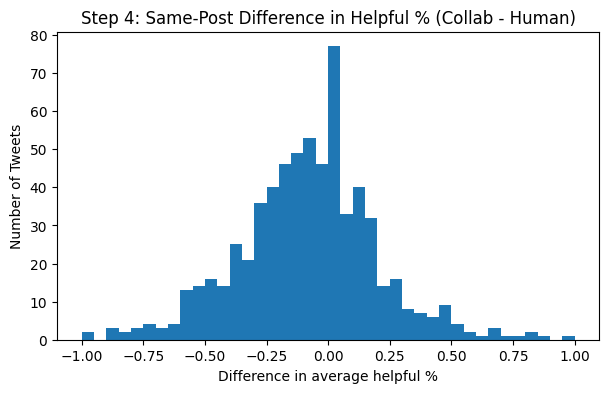

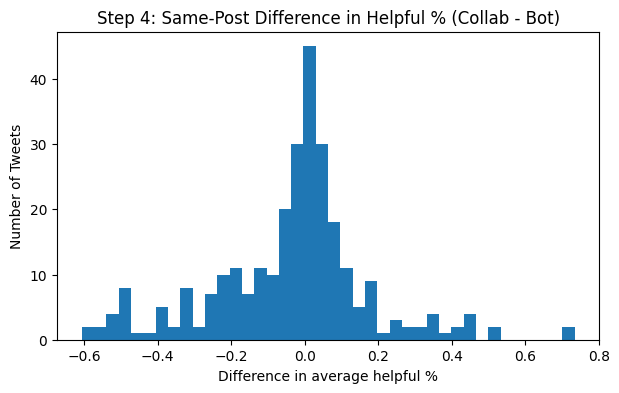

In [32]:
plt.figure(figsize=(7,4))
plt.hist(collab_human["diff_helpful"].dropna(), bins=40)
plt.title("Step 4: Same-Post Difference in Helpful % (Collab - Human)")
plt.xlabel("Difference in average helpful %")
plt.ylabel("Number of Tweets")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(collab_bot["diff_helpful"].dropna(), bins=40)
plt.title("Step 4: Same-Post Difference in Helpful % (Collab - Bot)")
plt.xlabel("Difference in average helpful %")
plt.ylabel("Number of Tweets")
plt.show()

In [33]:
analysis_notes["request_bucket"] = pd.cut(
    analysis_notes["request_count"],
    bins=[-0.1, 0, 1, 2, 5, 10, 20, 50, np.inf],
    labels=["0", "1", "2", "3-5", "6-10", "11-20", "21-50", "50+"]
)

request_bucket_summary = (
    analysis_notes.groupby(["note_type", "request_bucket"])
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean"),
        avg_helpful_or_somewhat_pct=("helpful_or_somewhat_pct", "mean"),
        avg_n_ratings=("n_ratings", "mean")
    )
    .reset_index()
)

# 百分比转为 0-100
for col in ["crh_pct", "nmr_pct", "avg_helpful_pct", "avg_helpful_or_somewhat_pct"]:
    request_bucket_summary[col] = request_bucket_summary[col] * 100

display(request_bucket_summary.head(20))

/tmp/ipykernel_14595/4263609764.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_notes.groupby(["note_type", "request_bucket"])


,note_type,request_bucket,n_notes,crh_pct,nmr_pct,avg_helpful_pct,avg_helpful_or_somewhat_pct,avg_n_ratings
0,bot,0,25,24.000000,68.000000,70.316618,72.414542,94.727273
1,bot,1,348,17.528736,75.862069,68.433907,70.906611,69.369048
2,bot,2,0,NaN,NaN,NaN,NaN,NaN
3,bot,3-5,0,NaN,NaN,NaN,NaN,NaN
4,bot,6-10,0,NaN,NaN,NaN,NaN,NaN
5,bot,11-20,0,NaN,NaN,NaN,NaN,NaN
6,bot,21-50,0,NaN,NaN,NaN,NaN,NaN
7,bot,50+,0,NaN,NaN,NaN,NaN,NaN
8,collab,0,1053,1.044634,75.308642,32.707379,38.708431,7.361769
9,collab,1,9825,0.977099,76.956743,47.828911,54.501410,15.796767


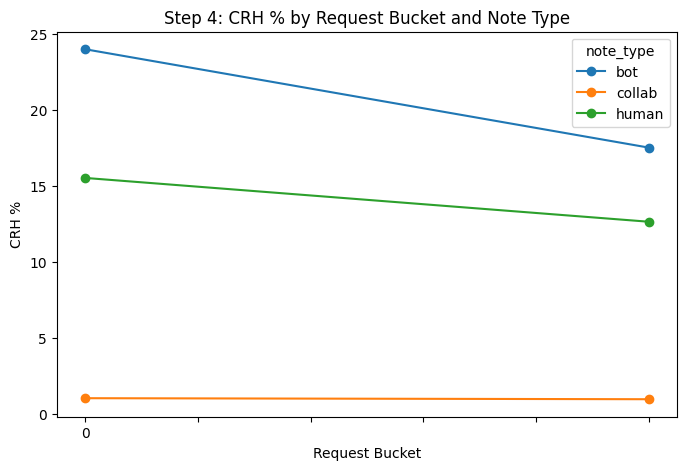

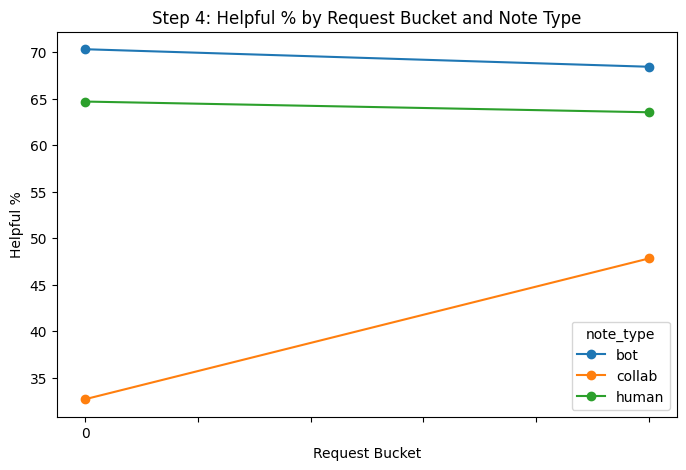

In [34]:
request_crh = request_bucket_summary.pivot(
    index="request_bucket",
    columns="note_type",
    values="crh_pct"
).sort_index()

request_helpful = request_bucket_summary.pivot(
    index="request_bucket",
    columns="note_type",
    values="avg_helpful_pct"
).sort_index()

request_crh.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Step 4: CRH % by Request Bucket and Note Type")
plt.xlabel("Request Bucket")
plt.ylabel("CRH %")
plt.show()

request_helpful.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Step 4: Helpful % by Request Bucket and Note Type")
plt.xlabel("Request Bucket")
plt.ylabel("Helpful %")
plt.show()

In [35]:
classification_summary = (
    analysis_notes.groupby(["classification", "note_type"])
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct"]:
    classification_summary[col] = classification_summary[col] * 100

display(classification_summary.sort_values(["classification", "note_type"]).head(30))

,classification,note_type,n_notes,crh_pct,nmr_pct,avg_helpful_pct
0,MISINFORMED_OR_POTENTIALLY_MISLEADING,bot,373,17.962466,75.335121,68.493590
1,MISINFORMED_OR_POTENTIALLY_MISLEADING,collab,5879,1.820037,88.637523,55.831545
2,MISINFORMED_OR_POTENTIALLY_MISLEADING,human,948,15.928270,77.637131,66.886186
3,NOT_MISLEADING,collab,4997,0.000000,62.897739,31.386885
4,NOT_MISLEADING,human,222,0.000000,84.684685,49.708248


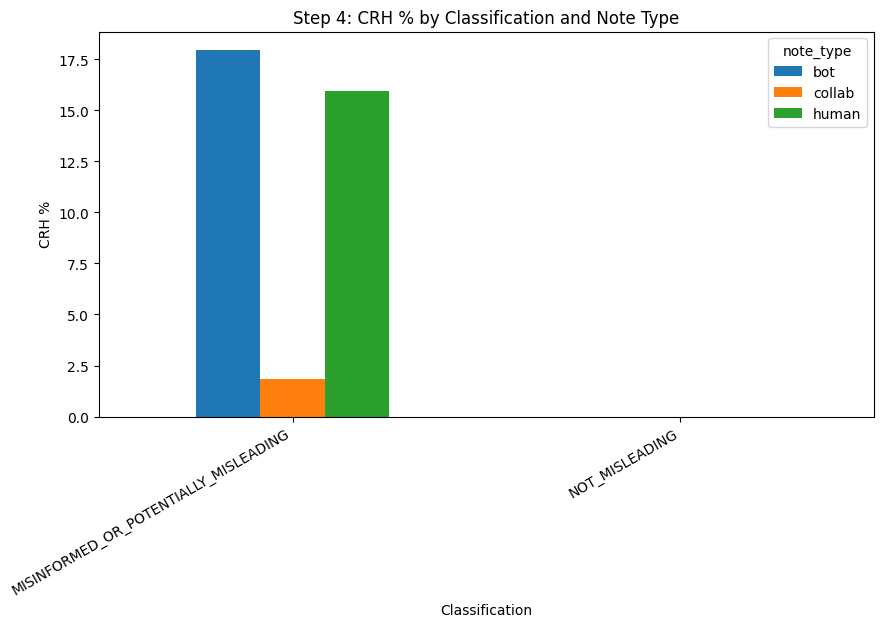

In [36]:
class_crh = classification_summary.pivot(
    index="classification",
    columns="note_type",
    values="crh_pct"
).fillna(0)

class_crh.plot(kind="bar", figsize=(10,5))
plt.title("Step 4: CRH % by Classification and Note Type")
plt.xlabel("Classification")
plt.ylabel("CRH %")
plt.xticks(rotation=30, ha="right")
plt.show()

In [37]:
media_summary = (
    analysis_notes.groupby(["isMediaNote", "note_type"])
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean"),
        avg_helpful_or_somewhat_pct=("helpful_or_somewhat_pct", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct", "avg_helpful_or_somewhat_pct"]:
    media_summary[col] = media_summary[col] * 100

display(media_summary)

,isMediaNote,note_type,n_notes,crh_pct,nmr_pct,avg_helpful_pct,avg_helpful_or_somewhat_pct
0,0,bot,373,17.962466,75.335121,68.493590,70.954413
1,0,collab,10878,0.983637,76.797205,46.693047,53.315109
2,0,human,1015,11.822660,79.408867,63.357000,65.709701
3,1,human,155,20.000000,76.129032,65.362733,67.723410


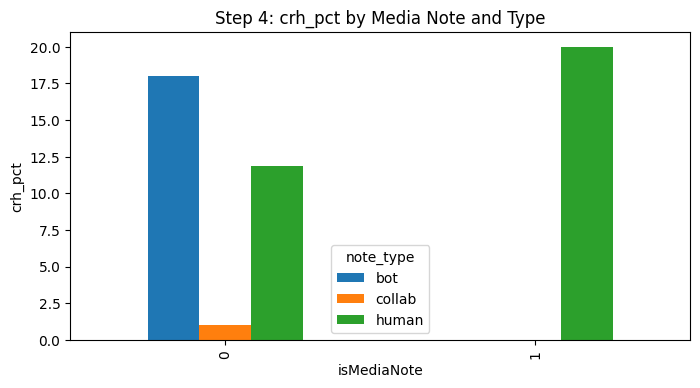

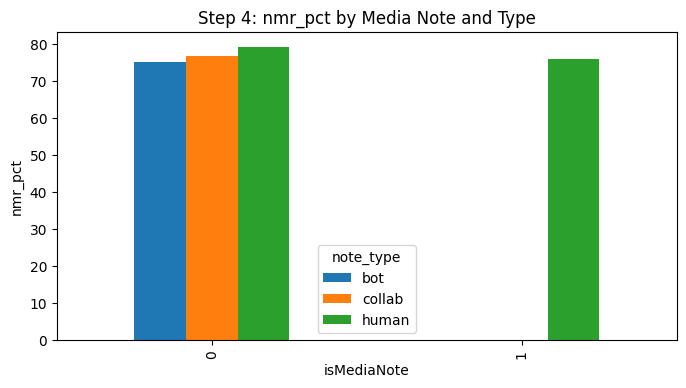

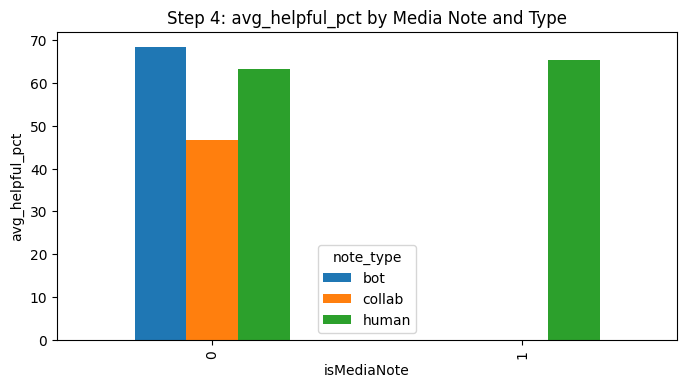

In [38]:
for metric in ["crh_pct", "nmr_pct", "avg_helpful_pct"]:
    pivot_df = media_summary.pivot(
        index="isMediaNote",
        columns="note_type",
        values=metric
    ).fillna(0)

    pivot_df.plot(kind="bar", figsize=(8,4))
    plt.title(f"Step 4: {metric} by Media Note and Type")
    plt.xlabel("isMediaNote")
    plt.ylabel(metric)
    plt.show()

In [39]:
analysis_notes["summary_len_bucket"] = pd.cut(
    analysis_notes["summary_len"],
    bins=[-0.1, 50, 100, 150, 200, 300, np.inf],
    labels=["0-50", "51-100", "101-150", "151-200", "201-300", "300+"]
)

length_summary = (
    analysis_notes.groupby(["summary_len_bucket", "note_type"])
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct"]:
    length_summary[col] = length_summary[col] * 100

display(length_summary.head(20))

/tmp/ipykernel_14595/259758200.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_notes.groupby(["summary_len_bucket", "note_type"])


,summary_len_bucket,note_type,n_notes,crh_pct,nmr_pct,avg_helpful_pct
0,0-50,bot,0,NaN,NaN,NaN
1,0-50,collab,0,NaN,NaN,NaN
2,0-50,human,25,0.000000,68.000000,48.695063
3,51-100,bot,0,NaN,NaN,NaN
4,51-100,collab,0,NaN,NaN,NaN
5,51-100,human,76,7.894737,73.684211,56.077972
6,101-150,bot,1,0.000000,100.000000,88.888889
7,101-150,collab,2,0.000000,100.000000,100.000000
8,101-150,human,132,8.333333,78.787879,58.522336
9,151-200,bot,11,27.272727,72.727273,64.828587


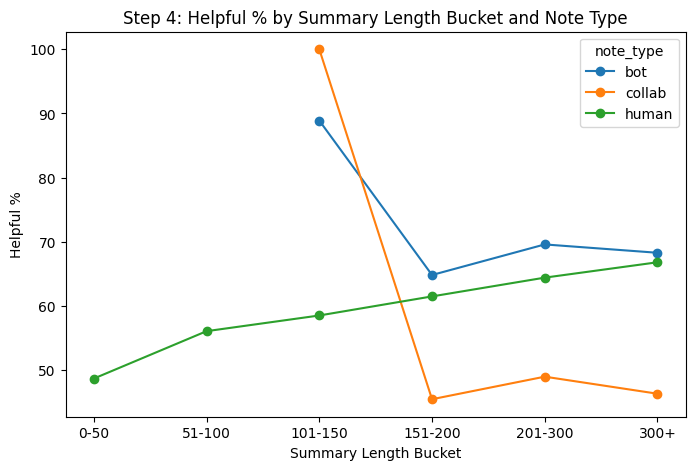

In [40]:
length_helpful = length_summary.pivot(
    index="summary_len_bucket",
    columns="note_type",
    values="avg_helpful_pct"
).sort_index()

length_helpful.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Step 4: Helpful % by Summary Length Bucket and Note Type")
plt.xlabel("Summary Length Bucket")
plt.ylabel("Helpful %")
plt.show()

In [41]:
collab_human_tweets = set(collab_human["tweetId"])

samepost_ch_notes = analysis_notes[
    analysis_notes["tweetId"].isin(collab_human_tweets)
].copy()

samepost_ch_summary = (
    samepost_ch_notes.groupby("note_type")
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean"),
        avg_helpful_or_somewhat_pct=("helpful_or_somewhat_pct", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct", "avg_helpful_or_somewhat_pct"]:
    samepost_ch_summary[col] = samepost_ch_summary[col] * 100

display(samepost_ch_summary)

,note_type,n_notes,crh_pct,nmr_pct,avg_helpful_pct,avg_helpful_or_somewhat_pct
0,bot,124,21.774194,74.193548,69.569099,72.226325
1,collab,3782,1.084082,84.241142,51.661847,57.090550
2,human,1170,12.905983,78.974359,63.622994,65.976752


In [42]:
collab_bot_tweets = set(collab_bot["tweetId"])

samepost_cb_notes = analysis_notes[
    analysis_notes["tweetId"].isin(collab_bot_tweets)
].copy()

samepost_cb_summary = (
    samepost_cb_notes.groupby("note_type")
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean"),
        avg_helpful_or_somewhat_pct=("helpful_or_somewhat_pct", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct", "avg_helpful_or_somewhat_pct"]:
    samepost_cb_summary[col] = samepost_cb_summary[col] * 100

display(samepost_cb_summary)

,note_type,n_notes,crh_pct,nmr_pct,avg_helpful_pct,avg_helpful_or_somewhat_pct
0,bot,373,17.962466,75.335121,68.493590,70.954413
1,collab,1068,1.217228,82.771536,62.716427,67.163021
2,human,141,21.276596,73.758865,69.413024,71.883085


In [43]:
collab_human.to_csv(STEP4_OUT / "samepost_collab_vs_human.csv", index=False)
collab_bot.to_csv(STEP4_OUT / "samepost_collab_vs_bot.csv", index=False)
request_bucket_summary.to_csv(STEP4_OUT / "request_bucket_summary.csv", index=False)
classification_summary.to_csv(STEP4_OUT / "classification_summary.csv", index=False)
media_summary.to_csv(STEP4_OUT / "media_summary.csv", index=False)
length_summary.to_csv(STEP4_OUT / "length_summary.csv", index=False)
samepost_ch_summary.to_csv(STEP4_OUT / "samepost_ch_summary.csv", index=False)
samepost_cb_summary.to_csv(STEP4_OUT / "samepost_cb_summary.csv", index=False)

analysis_notes.to_parquet(STEP4_OUT / "analysis_notes_step4.parquet", index=False)

print("saved to:", STEP4_OUT)
for p in sorted(STEP4_OUT.iterdir()):
    print(p.name)

saved to: /content/drive/MyDrive/494data/week8_cache/step4_outputs
analysis_notes_step4.parquet
classification_summary.csv
length_summary.csv
media_summary.csv
request_bucket_summary.csv
samepost_cb_summary.csv
samepost_ch_summary.csv
samepost_collab_vs_bot.csv
samepost_collab_vs_human.csv


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
import glob
import os

BASE = Path("/content/drive/MyDrive/494data")
CACHE = BASE / "week8_cache"
DEEP_OUT = CACHE / "step4_deep_dive_outputs"
DEEP_OUT.mkdir(exist_ok=True)

# 保险起见，analysis_notes / subset_ratings / status / notes 不在内存里就读回来
try:
    analysis_notes.shape
except NameError:
    analysis_notes = pd.read_parquet(CACHE / "step3_outputs/analysis_notes.parquet")

try:
    subset_ratings.shape
except NameError:
    subset_ratings = pd.read_parquet(CACHE / "step3_outputs/subset_ratings.parquet")

# 找 notes parquet
notes_latest = CACHE / "notes_latest.parquet"
if not notes_latest.exists():
    note_candidates = sorted(glob.glob(str(CACHE / "notes_*.parquet")))
    if len(note_candidates) == 0:
        raise FileNotFoundError("No notes parquet found in week8_cache")
    notes_latest = Path(note_candidates[-1])

# 只读后面需要的额外列
extra_note_cols = [
    "noteId",
    "trustworthySources",
    "misleadingOther",
    "misleadingFactualError",
    "misleadingManipulatedMedia",
    "misleadingOutdatedInformation",
    "misleadingMissingImportantContext",
    "misleadingUnverifiedClaimAsFact",
    "misleadingSatire",
    "notMisleadingOther",
    "notMisleadingFactuallyCorrect",
    "notMisleadingOutdatedButNotWhenWritten",
    "notMisleadingClearlySatire",
    "notMisleadingPersonalOpinion",
]

extra_notes = pd.read_parquet(notes_latest, columns=extra_note_cols)

analysis_notes["noteId"] = analysis_notes["noteId"].astype(str)
extra_notes["noteId"] = extra_notes["noteId"].astype(str)
subset_ratings["noteId"] = subset_ratings["noteId"].astype(str)

analysis_notes = analysis_notes.merge(extra_notes, on="noteId", how="left")

# 重新做 rating-level helper fields
subset_ratings["helpfulnessLevel_clean"] = (
    subset_ratings["helpfulnessLevel"].astype(str).str.strip().str.upper()
)
subset_ratings["is_helpful_strict"] = (
    subset_ratings["helpfulnessLevel_clean"] == "HELPFUL"
).astype(int)
subset_ratings["is_helpful_or_somewhat"] = (
    subset_ratings["helpfulnessLevel_clean"].isin(["HELPFUL", "SOMEWHAT_HELPFUL"])
).astype(int)
subset_ratings["has_suggestion"] = subset_ratings["suggestion"].notna() & (
    subset_ratings["suggestion"].astype(str).str.strip() != ""
)

# note-level rating aggregates
note_rating_extras = (
    subset_ratings.groupby("noteId", observed=False)
    .agg(
        n_ratings=("noteId", "size"),
        helpful_pct_strict=("is_helpful_strict", "mean"),
        helpful_or_somewhat_pct=("is_helpful_or_somewhat", "mean"),
        suggestion_count=("has_suggestion", "sum"),
        suggestion_share=("has_suggestion", "mean"),
    )
    .reset_index()
)

analysis_notes = analysis_notes.drop(
    columns=[
        c for c in [
            "n_ratings",
            "helpful_pct_strict",
            "helpful_or_somewhat_pct",
            "suggestion_count",
            "suggestion_share"
        ] if c in analysis_notes.columns
    ],
    errors="ignore"
).merge(note_rating_extras, on="noteId", how="left")

analysis_notes["n_ratings"] = analysis_notes["n_ratings"].fillna(0)
analysis_notes["suggestion_count"] = analysis_notes["suggestion_count"].fillna(0)
analysis_notes["suggestion_share"] = analysis_notes["suggestion_share"].fillna(0)

analysis_notes["is_crh"] = (analysis_notes["currentStatus_std"] == "CRH").astype(int)
analysis_notes["is_crnh"] = (analysis_notes["currentStatus_std"] == "CRNH").astype(int)
analysis_notes["is_nmr"] = (analysis_notes["currentStatus_std"] == "NMR").astype(int)

analysis_notes["summary"] = analysis_notes["summary"].fillna("").astype(str)
analysis_notes["summary_len"] = analysis_notes["summary"].str.len()

print(analysis_notes.shape)
display(analysis_notes.head())

(12421, 41)


,noteId,tweetId,noteAuthorParticipantId,createdAtMillis,classification,summary,isMediaNote,isCollaborativeNote,note_type,createdAtMillis_status,...,notMisleadingOther,notMisleadingFactuallyCorrect,notMisleadingOutdatedButNotWhenWritten,notMisleadingClearlySatire,notMisleadingPersonalOpinion,n_ratings,helpful_pct_strict,helpful_or_somewhat_pct,suggestion_count,suggestion_share
0,2027666887375573258,2027530195905736916,DAFF63AF82C670F0C5418BB0A13909385E1317F0C48F40...,1772268432837,MISINFORMED_OR_POTENTIALLY_MISLEADING,This is not Anthropic's headquarters. The AI c...,0,0,human,1.772268e+12,...,0,0,0,0,0,55.0,0.836364,0.854545,0.0,0.0
1,2021162208172880365,2021002549491302715,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1770717596464,MISINFORMED_OR_POTENTIALLY_MISLEADING,Congress shall make no law respecting an estab...,0,0,human,1.770718e+12,...,0,0,0,0,0,486.0,0.337449,0.341564,0.0,0.0
2,2025686681626796278,2025478658622976132,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1771796314995,MISINFORMED_OR_POTENTIALLY_MISLEADING,Bill Gates was not &quot;indicted&quot; in the...,1,0,human,1.771796e+12,...,0,0,0,0,0,49.0,0.714286,0.795918,0.0,0.0
3,2030972730938368293,2030773103563825387,B5E919251BCC971AC97D9C81A005C1F1A0C3D52BE20146...,1773056607361,MISINFORMED_OR_POTENTIALLY_MISLEADING,The number came from a website listing reports...,1,0,human,1.773057e+12,...,0,0,0,0,0,0.0,NaN,NaN,0.0,0.0
4,2025525278265459110,2025127875544817894,27005C91F2262A33F14511CD38A75AFFA57D1E072AEE7B...,1771757833435,MISINFORMED_OR_POTENTIALLY_MISLEADING,Poster later admitted that it may not have bee...,0,0,human,1.771758e+12,...,0,0,0,0,0,546.0,0.807692,0.811355,0.0,0.0


,age_bucket,note_type,n_notes,crh_pct,nmr_pct,avg_helpful_pct,avg_n_ratings
0,0-1d,bot,10,0.000000,100.000000,NaN,0.000000
1,0-1d,collab,197,1.522843,72.081218,NaN,0.000000
2,0-1d,human,21,9.523810,66.666667,NaN,0.000000
3,1-3d,bot,9,33.333333,55.555556,72.697671,92.666667
4,1-3d,collab,363,3.305785,76.584022,50.063005,8.812672
5,1-3d,human,35,17.142857,71.428571,61.789837,107.885714
6,3-7d,bot,105,6.666667,82.857143,67.319997,25.609524
7,3-7d,collab,1056,1.136364,77.367424,51.761922,11.432765
8,3-7d,human,108,13.888889,80.555556,73.189333,114.546296
9,7-14d,bot,81,17.283951,77.777778,65.555608,52.938272


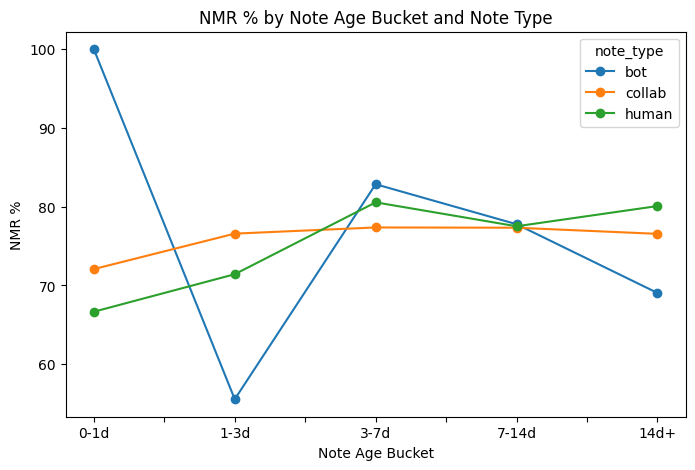

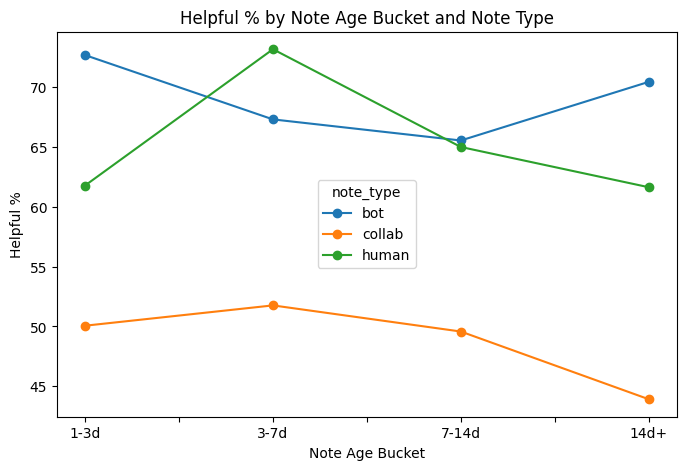

In [45]:
# 用当前数据里的最新交互时间做一个 snapshot proxy
snapshot_ts = max(
    analysis_notes["createdAtMillis"].max(),
    subset_ratings["createdAtMillis"].max()
)

analysis_notes["note_age_hours"] = (snapshot_ts - analysis_notes["createdAtMillis"]) / (1000 * 60 * 60)
analysis_notes["note_age_days"] = analysis_notes["note_age_hours"] / 24

analysis_notes["age_bucket"] = pd.cut(
    analysis_notes["note_age_hours"],
    bins=[-0.1, 24, 72, 168, 336, np.inf],
    labels=["0-1d", "1-3d", "3-7d", "7-14d", "14d+"]
)

age_summary = (
    analysis_notes.groupby(["age_bucket", "note_type"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean"),
        avg_n_ratings=("n_ratings", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct"]:
    age_summary[col] = age_summary[col] * 100

display(age_summary)

age_plot = age_summary.pivot(index="age_bucket", columns="note_type", values="nmr_pct").sort_index()
age_plot.plot(kind="line", marker="o", figsize=(8,5))
plt.title("NMR % by Note Age Bucket and Note Type")
plt.xlabel("Note Age Bucket")
plt.ylabel("NMR %")
plt.show()

age_helpful_plot = age_summary.pivot(index="age_bucket", columns="note_type", values="avg_helpful_pct").sort_index()
age_helpful_plot.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Helpful % by Note Age Bucket and Note Type")
plt.xlabel("Note Age Bucket")
plt.ylabel("Helpful %")
plt.show()

,note_type,suggestion_bucket,n_notes,crh_pct,nmr_pct,avg_helpful_pct,avg_n_ratings
0,bot,0,373,17.962466,75.335121,68.493590,65.281501
1,bot,1,0,NaN,NaN,NaN,NaN
2,bot,2,0,NaN,NaN,NaN,NaN
3,bot,3-5,0,NaN,NaN,NaN,NaN
4,bot,6-10,0,NaN,NaN,NaN,NaN
5,bot,10+,0,NaN,NaN,NaN,NaN
6,collab,0,6633,0.723654,64.420323,65.028611,7.876979
7,collab,1,1716,1.398601,96.095571,30.821335,9.376457
8,collab,2,2196,0.774135,97.131148,25.212267,15.515027
9,collab,3-5,268,4.104478,92.164179,39.589080,54.186567


,note_type,suggestion_bucket,n_notes,crh_pct,nmr_pct,avg_helpful_pct,avg_n_ratings
6,collab,0,6633,0.723654,64.420323,65.028611,7.876979
7,collab,1,1716,1.398601,96.095571,30.821335,9.376457
8,collab,2,2196,0.774135,97.131148,25.212267,15.515027
9,collab,3-5,268,4.104478,92.164179,39.589080,54.186567
10,collab,6-10,55,7.272727,85.454545,39.703318,144.163636
11,collab,10+,10,30.000000,50.000000,48.354975,292.000000


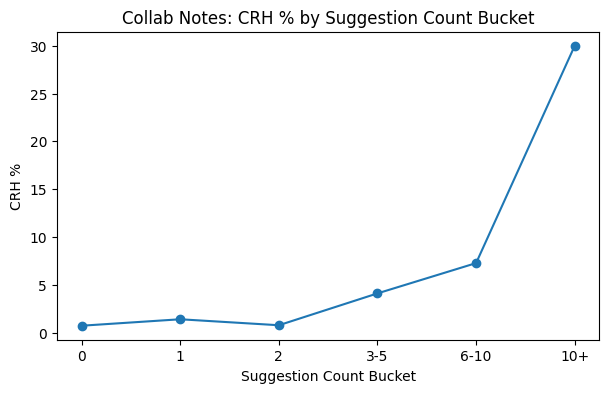

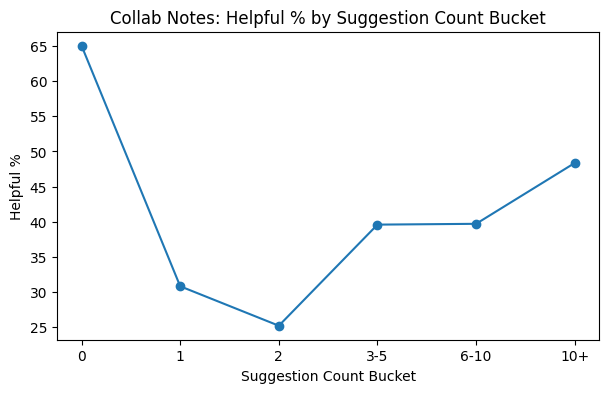

,metric,correlation_with_suggestion_count
0,crh,0.082926
1,nmr,0.255214
2,helpful_pct,-0.325965
3,n_ratings,0.358546


In [47]:
analysis_notes["suggestion_bucket"] = pd.cut(
    analysis_notes["suggestion_count"],
    bins=[-0.1, 0, 1, 2, 5, 10, np.inf],
    labels=["0", "1", "2", "3-5", "6-10", "10+"]
)

suggestion_summary = (
    analysis_notes.groupby(["note_type", "suggestion_bucket"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean"),
        avg_n_ratings=("n_ratings", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct"]:
    suggestion_summary[col] = suggestion_summary[col] * 100

display(suggestion_summary)

# 专门看 collab
collab_suggestion_summary = suggestion_summary[suggestion_summary["note_type"] == "collab"].copy()
display(collab_suggestion_summary)

collab_sugg_plot = collab_suggestion_summary.set_index("suggestion_bucket")["crh_pct"]
collab_sugg_plot.plot(kind="line", marker="o", figsize=(7,4))
plt.title("Collab Notes: CRH % by Suggestion Count Bucket")
plt.xlabel("Suggestion Count Bucket")
plt.ylabel("CRH %")
plt.show()

collab_sugg_helpful = collab_suggestion_summary.set_index("suggestion_bucket")["avg_helpful_pct"]
collab_sugg_helpful.plot(kind="line", marker="o", figsize=(7,4))
plt.title("Collab Notes: Helpful % by Suggestion Count Bucket")
plt.xlabel("Suggestion Count Bucket")
plt.ylabel("Helpful %")
plt.show()

# suggestion_count 和表现的简单相关
collab_only = analysis_notes[analysis_notes["note_type"] == "collab"].copy()

corr_table = pd.DataFrame({
    "metric": ["crh", "nmr", "helpful_pct", "n_ratings"],
    "correlation_with_suggestion_count": [
        collab_only["suggestion_count"].corr(collab_only["is_crh"]),
        collab_only["suggestion_count"].corr(collab_only["is_nmr"]),
        collab_only["suggestion_count"].corr(collab_only["helpful_pct_strict"]),
        collab_only["suggestion_count"].corr(collab_only["n_ratings"]),
    ]
})

display(corr_table)

,competition_bucket,note_type,n_notes,crh_pct,nmr_pct,avg_helpful_pct,avg_n_ratings
0,1,bot,0,NaN,NaN,NaN,NaN
1,1,collab,2317,1.467415,54.639620,66.642196,5.041864
2,1,human,0,NaN,NaN,NaN,NaN
3,2,bot,55,20.000000,70.909091,70.426915,39.127273
4,2,collab,1639,0.854179,78.523490,39.529569,7.946309
5,2,human,86,13.953488,76.744186,68.836269,63.011628
6,3-5,bot,183,16.393443,77.595628,71.618191,35.890710
7,3-5,collab,2851,1.157489,82.462294,41.748079,10.818309
8,3-5,human,396,16.666667,75.505051,65.719682,96.063131
9,6-10,bot,112,18.750000,75.000000,64.575830,79.508929


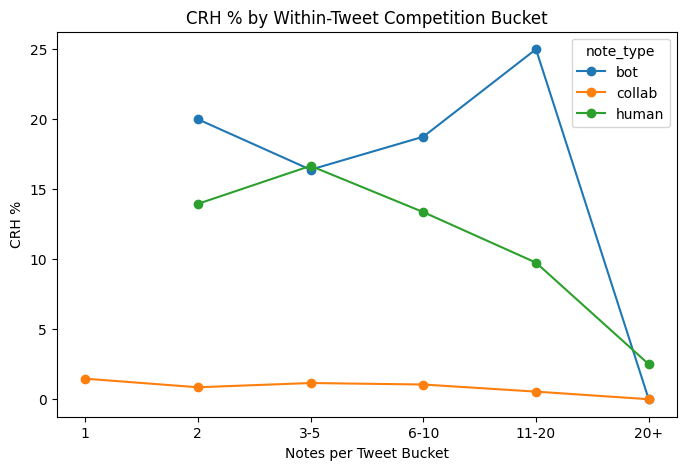

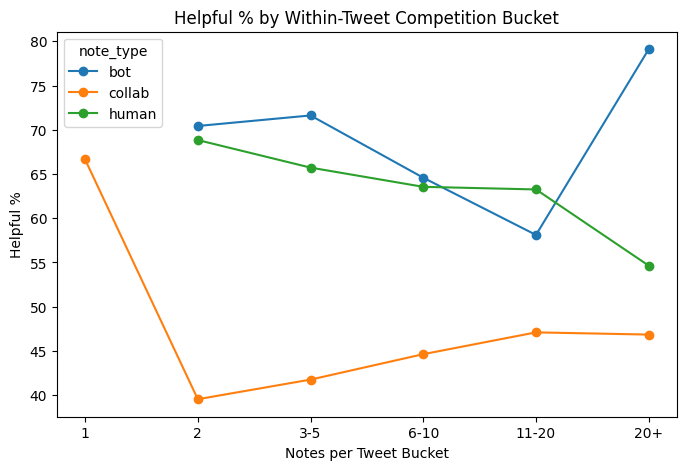

In [48]:
notes_per_tweet = (
    analysis_notes.groupby("tweetId", observed=False)
    .size()
    .reset_index(name="notes_per_tweet")
)

analysis_notes = analysis_notes.drop(columns=["notes_per_tweet"], errors="ignore").merge(
    notes_per_tweet, on="tweetId", how="left"
)

analysis_notes["competition_bucket"] = pd.cut(
    analysis_notes["notes_per_tweet"],
    bins=[0, 1, 2, 5, 10, 20, np.inf],
    labels=["1", "2", "3-5", "6-10", "11-20", "20+"]
)

competition_summary = (
    analysis_notes.groupby(["competition_bucket", "note_type"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean"),
        avg_n_ratings=("n_ratings", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct"]:
    competition_summary[col] = competition_summary[col] * 100

display(competition_summary)

comp_plot = competition_summary.pivot(index="competition_bucket", columns="note_type", values="crh_pct").sort_index()
comp_plot.plot(kind="line", marker="o", figsize=(8,5))
plt.title("CRH % by Within-Tweet Competition Bucket")
plt.xlabel("Notes per Tweet Bucket")
plt.ylabel("CRH %")
plt.show()

comp_helpful_plot = competition_summary.pivot(index="competition_bucket", columns="note_type", values="avg_helpful_pct").sort_index()
comp_helpful_plot.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Helpful % by Within-Tweet Competition Bucket")
plt.xlabel("Notes per Tweet Bucket")
plt.ylabel("Helpful %")
plt.show()

,claim_type,note_type,n_notes,crh_pct,nmr_pct,avg_helpful_pct
0,misleadingFactualError,bot,278,17.625899,74.460432,67.295677
1,misleadingFactualError,human,600,18.500000,76.666667,70.594685
2,misleadingManipulatedMedia,bot,192,21.354167,71.354167,68.397801
3,misleadingManipulatedMedia,human,124,20.967742,72.580645,76.326696
4,misleadingMissingImportantContext,bot,311,19.292605,73.954984,67.430117
5,misleadingMissingImportantContext,human,655,14.809160,79.694656,66.646957
6,misleadingOther,human,106,14.150943,73.584906,61.887928
7,misleadingOutdatedInformation,bot,55,16.363636,76.363636,66.621993
8,misleadingOutdatedInformation,human,242,15.289256,75.619835,64.768387
9,misleadingSatire,bot,8,25.000000,62.500000,65.649524


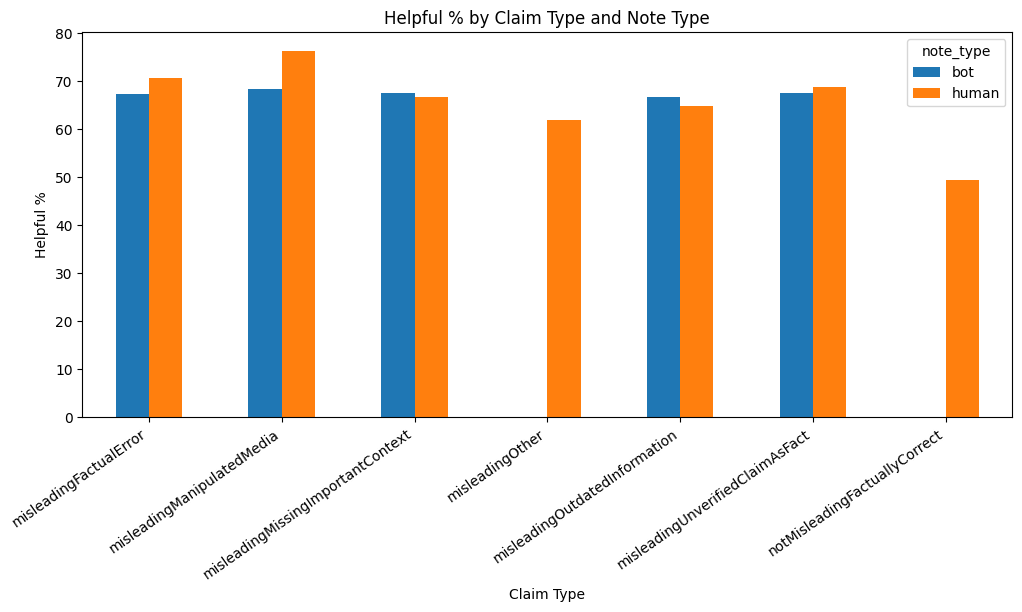

In [49]:
claim_cols = [
    "misleadingFactualError",
    "misleadingManipulatedMedia",
    "misleadingOutdatedInformation",
    "misleadingMissingImportantContext",
    "misleadingUnverifiedClaimAsFact",
    "misleadingSatire",
    "misleadingOther",
    "notMisleadingFactuallyCorrect",
    "notMisleadingOutdatedButNotWhenWritten",
    "notMisleadingClearlySatire",
    "notMisleadingPersonalOpinion",
    "notMisleadingOther",
]

# 转成长表，只保留标记为 1 的 claim
claim_long = []
for col in claim_cols:
    tmp = analysis_notes.loc[analysis_notes[col] == 1, [
        "noteId", "note_type", "is_crh", "is_nmr", "helpful_pct_strict", col
    ]].copy()
    if len(tmp) > 0:
        tmp["claim_type"] = col
        claim_long.append(tmp[["noteId", "note_type", "is_crh", "is_nmr", "helpful_pct_strict", "claim_type"]])

claim_long = pd.concat(claim_long, ignore_index=True) if len(claim_long) > 0 else pd.DataFrame()

claim_summary = (
    claim_long.groupby(["claim_type", "note_type"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct"]:
    claim_summary[col] = claim_summary[col] * 100

display(claim_summary.sort_values(["claim_type", "note_type"]))

# 只画样本量相对大的 claim_type
claim_plot_df = claim_summary.copy()
claim_totals = claim_plot_df.groupby("claim_type", observed=False)["n_notes"].sum().reset_index()
big_claims = set(claim_totals.loc[claim_totals["n_notes"] >= 100, "claim_type"])
claim_plot_df = claim_plot_df[claim_plot_df["claim_type"].isin(big_claims)]

claim_pivot = claim_plot_df.pivot(index="claim_type", columns="note_type", values="avg_helpful_pct").fillna(0)
claim_pivot.plot(kind="bar", figsize=(12,5))
plt.title("Helpful % by Claim Type and Note Type")
plt.xlabel("Claim Type")
plt.ylabel("Helpful %")
plt.xticks(rotation=35, ha="right")
plt.show()

,note_type,n_notes,ever_non_nmr_pct,regressed_to_nmr_pct,first_crh_then_nmr_pct,first_crnh_then_nmr_pct
0,bot,373,24.664879,3.485255,1.608579,1.876676
1,collab,10878,3.015260,0.974444,0.239015,0.735429
2,human,1170,24.358974,5.555556,2.564103,2.991453


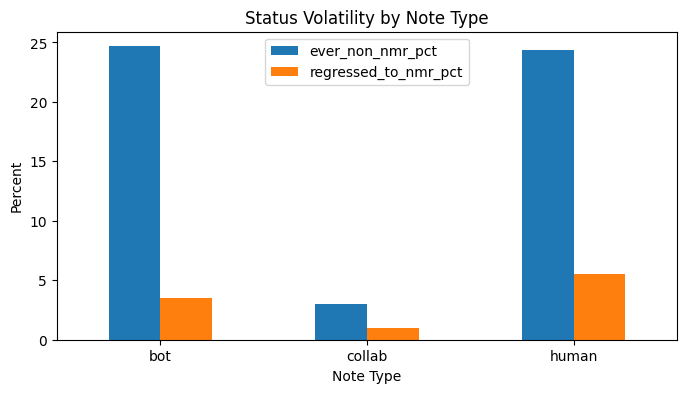

In [50]:
analysis_notes["ever_non_nmr"] = analysis_notes["firstNonNMRStatus_std"].notna().astype(int)
analysis_notes["regressed_to_nmr"] = (
    analysis_notes["firstNonNMRStatus_std"].notna() &
    (analysis_notes["currentStatus_std"] == "NMR")
).astype(int)

analysis_notes["first_crh_then_nmr"] = (
    (analysis_notes["firstNonNMRStatus_std"] == "CRH") &
    (analysis_notes["currentStatus_std"] == "NMR")
).astype(int)

analysis_notes["first_crnh_then_nmr"] = (
    (analysis_notes["firstNonNMRStatus_std"] == "CRNH") &
    (analysis_notes["currentStatus_std"] == "NMR")
).astype(int)

volatility_summary = (
    analysis_notes.groupby("note_type", observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        ever_non_nmr_pct=("ever_non_nmr", "mean"),
        regressed_to_nmr_pct=("regressed_to_nmr", "mean"),
        first_crh_then_nmr_pct=("first_crh_then_nmr", "mean"),
        first_crnh_then_nmr_pct=("first_crnh_then_nmr", "mean")
    )
    .reset_index()
)

for col in [
    "ever_non_nmr_pct",
    "regressed_to_nmr_pct",
    "first_crh_then_nmr_pct",
    "first_crnh_then_nmr_pct"
]:
    volatility_summary[col] = volatility_summary[col] * 100

display(volatility_summary)

vol_plot = volatility_summary.set_index("note_type")[[
    "ever_non_nmr_pct",
    "regressed_to_nmr_pct"
]]
vol_plot.plot(kind="bar", figsize=(8,4))
plt.title("Status Volatility by Note Type")
plt.xlabel("Note Type")
plt.ylabel("Percent")
plt.xticks(rotation=0)
plt.show()

,rating_bucket,note_type,n_notes,crh_pct,nmr_pct,avg_helpful_pct
0,0-5,bot,70,1.428571,80.000000,73.863636
1,0-5,collab,7028,0.085373,67.145703,42.582113
2,0-5,human,120,1.666667,75.833333,54.040404
3,6-10,bot,42,0.000000,100.000000,73.920068
4,6-10,collab,1284,0.077882,99.454829,52.197405
5,6-10,human,47,0.000000,97.872340,67.667173
6,11-20,bot,46,4.347826,93.478261,65.390031
7,11-20,collab,1070,0.373832,97.757009,51.700360
8,11-20,human,100,4.000000,91.000000,64.474071
9,21-50,bot,93,22.580645,72.043011,67.361964


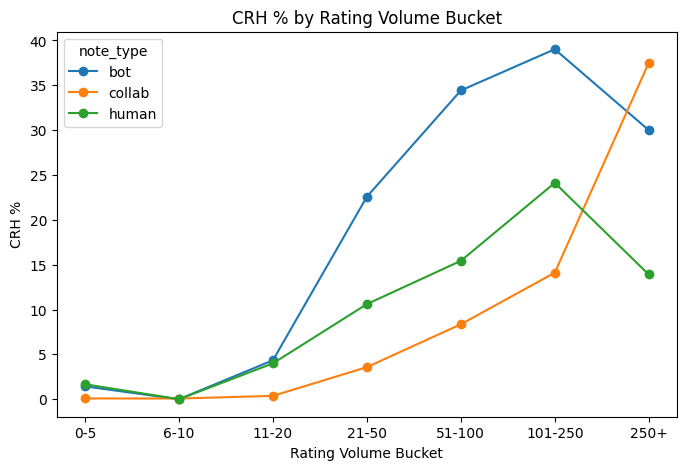

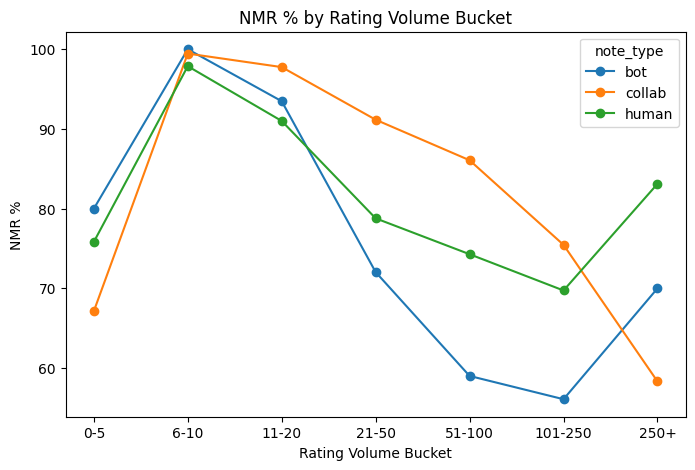

In [51]:
analysis_notes["rating_bucket"] = pd.cut(
    analysis_notes["n_ratings"],
    bins=[-0.1, 5, 10, 20, 50, 100, 250, np.inf],
    labels=["0-5", "6-10", "11-20", "21-50", "51-100", "101-250", "250+"]
)

rating_volume_summary = (
    analysis_notes.groupby(["rating_bucket", "note_type"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct"]:
    rating_volume_summary[col] = rating_volume_summary[col] * 100

display(rating_volume_summary)

rv_crh = rating_volume_summary.pivot(index="rating_bucket", columns="note_type", values="crh_pct").sort_index()
rv_crh.plot(kind="line", marker="o", figsize=(8,5))
plt.title("CRH % by Rating Volume Bucket")
plt.xlabel("Rating Volume Bucket")
plt.ylabel("CRH %")
plt.show()

rv_nmr = rating_volume_summary.pivot(index="rating_bucket", columns="note_type", values="nmr_pct").sort_index()
rv_nmr.plot(kind="line", marker="o", figsize=(8,5))
plt.title("NMR % by Rating Volume Bucket")
plt.xlabel("Rating Volume Bucket")
plt.ylabel("NMR %")
plt.show()

In [52]:
author_summary = (
    analysis_notes.groupby(["note_type", "noteAuthorParticipantId"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "avg_helpful_pct"]:
    author_summary[col] = author_summary[col] * 100

display(author_summary.head())

# 作者集中度：前10作者占比
author_concentration = (
    author_summary.sort_values(["note_type", "n_notes"], ascending=[True, False])
    .groupby("note_type", observed=False)
    .head(10)
    .groupby("note_type", observed=False)["n_notes"]
    .sum()
    .reset_index(name="top10_author_note_count")
)

total_by_type = (
    author_summary.groupby("note_type", observed=False)["n_notes"]
    .sum()
    .reset_index(name="total_note_count")
)

author_concentration = author_concentration.merge(total_by_type, on="note_type", how="left")
author_concentration["top10_share_pct"] = (
    author_concentration["top10_author_note_count"] /
    author_concentration["total_note_count"] * 100
)

display(author_concentration)

# 去掉作者高频影响：每位作者只保留第一条 note
author_first_note = (
    analysis_notes.sort_values("createdAtMillis")
    .groupby(["note_type", "noteAuthorParticipantId"], observed=False)
    .head(1)
    .copy()
)

author_first_summary = (
    author_first_note.groupby("note_type", observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct"]:
    author_first_summary[col] = author_first_summary[col] * 100

display(author_first_summary)

,note_type,noteAuthorParticipantId,n_notes,crh_pct,avg_helpful_pct
0,bot,191F8B3CF22C564E5E0E7D70D50E94C2074763B001F371...,2,0.000000,86.549376
1,bot,2E17D975042F20F745DAE5FCC7785CD2731C33F93D3DE6...,1,0.000000,44.444444
2,bot,321BEBF06B9C14296569E1A26D2EB521A2B16AB2039AB9...,58,22.413793,72.964980
3,bot,3DB2C88F21A0C5421B373B4CAAC2C507807F2D85C8914D...,53,37.735849,69.769269
4,bot,43D4A2A76D6602246E751C796A2347AE546F983DF21676...,3,0.000000,41.625362


,note_type,top10_author_note_count,total_note_count,top10_share_pct
0,bot,335,373,89.812332
1,collab,10878,10878,100.000000
2,human,123,1170,10.512821


,note_type,n_notes,crh_pct,nmr_pct,avg_helpful_pct
0,bot,21,23.809524,66.666667,68.367713
1,collab,1,0.000000,0.000000,100.000000
2,human,877,12.542759,78.449259,62.656547


,note_type,has_trustworthy_sources,n_notes,crh_pct,nmr_pct,avg_helpful_pct,avg_n_ratings
0,bot,0,1,0.000000,100.000000,44.444444,18.000000
1,bot,1,372,18.010753,75.268817,68.563096,65.408602
2,collab,0,10878,0.983637,76.797205,46.693047,11.746645
3,human,0,117,1.709402,75.213675,50.517106,211.418803
4,human,1,1053,14.150047,79.392213,65.114083,259.120608


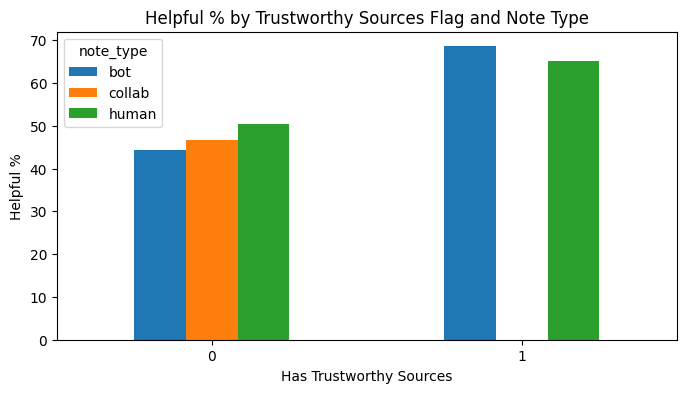

In [53]:
analysis_notes["has_trustworthy_sources"] = analysis_notes["trustworthySources"].fillna(0).astype(float).gt(0).astype(int)

source_summary = (
    analysis_notes.groupby(["note_type", "has_trustworthy_sources"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean"),
        avg_n_ratings=("n_ratings", "mean")
    )
    .reset_index()
)

for col in ["crh_pct", "nmr_pct", "avg_helpful_pct"]:
    source_summary[col] = source_summary[col] * 100

display(source_summary)

source_helpful = source_summary.pivot(index="has_trustworthy_sources", columns="note_type", values="avg_helpful_pct").fillna(0)
source_helpful.plot(kind="bar", figsize=(8,4))
plt.title("Helpful % by Trustworthy Sources Flag and Note Type")
plt.xlabel("Has Trustworthy Sources")
plt.ylabel("Helpful %")
plt.xticks(rotation=0)
plt.show()

,note_type,n_notes,avg_summary_len,url_like_pct,has_number_pct,avg_sentence_proxy,avg_quote_entity_count,avg_punct_per_100_chars,avg_helpful_pct
0,bot,373,385.391421,100.000000,91.957105,7.900804,0.375335,3.021153,68.493590
1,collab,10878,394.570050,100.000000,95.716124,8.681927,0.298309,3.232701,46.693047
2,human,1170,299.621368,87.606838,76.923077,6.212821,0.300855,2.898440,63.622994


,sentence_bucket,note_type,n_notes,avg_helpful_pct,crh_pct,nmr_pct
0,1,bot,0,NaN,NaN,NaN
1,1,collab,0,NaN,NaN,NaN
2,1,human,15,51.794076,0.000000,60.000000
3,2,bot,0,NaN,NaN,NaN
4,2,collab,0,NaN,NaN,NaN
5,2,human,65,55.410925,6.153846,73.846154
6,3,bot,4,69.973545,25.000000,75.000000
7,3,collab,16,38.231293,0.000000,81.250000
8,3,human,162,59.398921,8.024691,82.098765
9,4-5,bot,56,66.962560,17.857143,76.785714


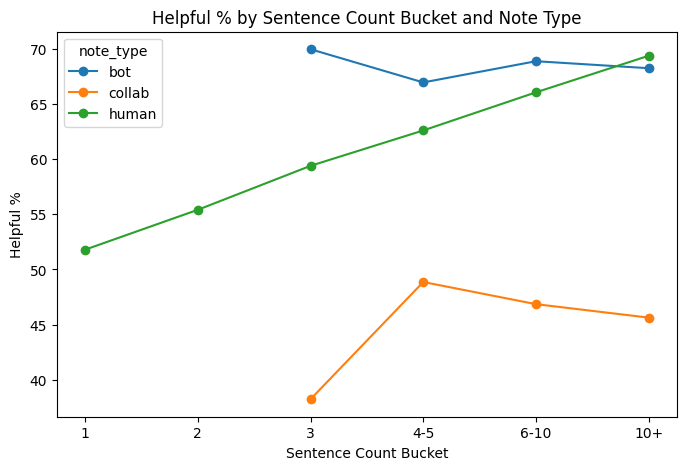

In [54]:
analysis_notes["has_url_like_text"] = analysis_notes["summary"].str.contains(r"http|www\.|\.com|\.org|\.net", case=False, regex=True).astype(int)
analysis_notes["has_number"] = analysis_notes["summary"].str.contains(r"\d", regex=True).astype(int)
analysis_notes["n_sentences_proxy"] = analysis_notes["summary"].str.count(r"[.!?。！？]") + 1
analysis_notes["quote_entity_count"] = analysis_notes["summary"].str.count(r"&quot;")
analysis_notes["punct_count"] = analysis_notes["summary"].str.count(r"[,.!?;:，。！？；：]")
analysis_notes["punct_per_100_chars"] = np.where(
    analysis_notes["summary_len"] > 0,
    analysis_notes["punct_count"] / analysis_notes["summary_len"] * 100,
    0
)

text_feature_summary = (
    analysis_notes.groupby("note_type", observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        avg_summary_len=("summary_len", "mean"),
        url_like_pct=("has_url_like_text", "mean"),
        has_number_pct=("has_number", "mean"),
        avg_sentence_proxy=("n_sentences_proxy", "mean"),
        avg_quote_entity_count=("quote_entity_count", "mean"),
        avg_punct_per_100_chars=("punct_per_100_chars", "mean"),
        avg_helpful_pct=("helpful_pct_strict", "mean")
    )
    .reset_index()
)

for col in ["url_like_pct", "has_number_pct", "avg_helpful_pct"]:
    text_feature_summary[col] = text_feature_summary[col] * 100

display(text_feature_summary)

# 按句子数分桶看表现
analysis_notes["sentence_bucket"] = pd.cut(
    analysis_notes["n_sentences_proxy"],
    bins=[0, 1, 2, 3, 5, 10, np.inf],
    labels=["1", "2", "3", "4-5", "6-10", "10+"]
)

sentence_summary = (
    analysis_notes.groupby(["sentence_bucket", "note_type"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        avg_helpful_pct=("helpful_pct_strict", "mean"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean")
    )
    .reset_index()
)

for col in ["avg_helpful_pct", "crh_pct", "nmr_pct"]:
    sentence_summary[col] = sentence_summary[col] * 100

display(sentence_summary)

sent_plot = sentence_summary.pivot(index="sentence_bucket", columns="note_type", values="avg_helpful_pct").sort_index()
sent_plot.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Helpful % by Sentence Count Bucket and Note Type")
plt.xlabel("Sentence Count Bucket")
plt.ylabel("Helpful %")
plt.show()

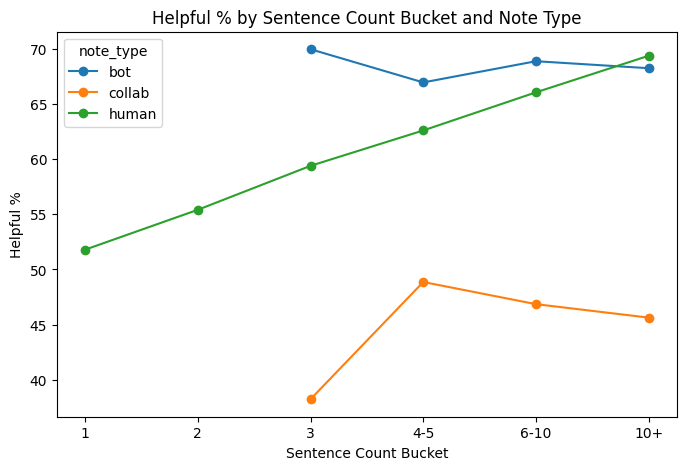

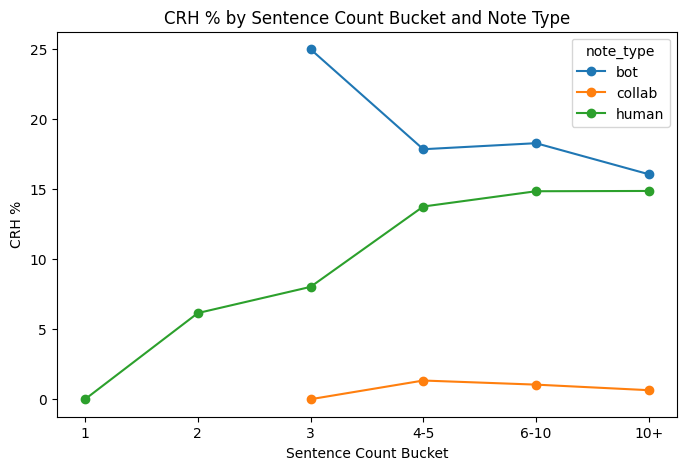

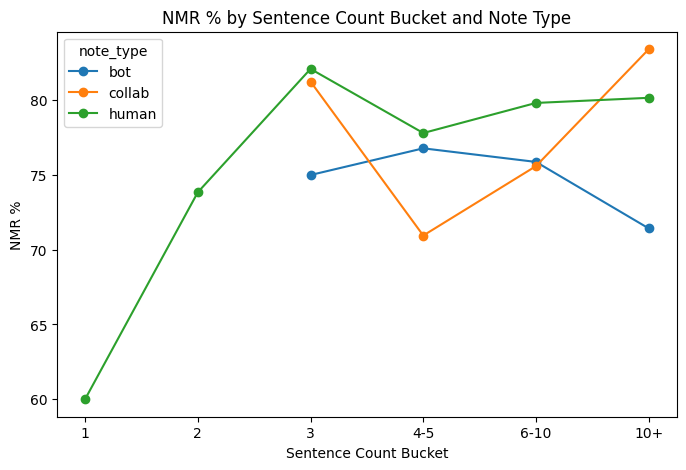

In [55]:
import matplotlib.pyplot as plt

# 1) Helpful %
sent_helpful = sentence_summary.pivot(
    index="sentence_bucket",
    columns="note_type",
    values="avg_helpful_pct"
).sort_index()

sent_helpful.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Helpful % by Sentence Count Bucket and Note Type")
plt.xlabel("Sentence Count Bucket")
plt.ylabel("Helpful %")
plt.show()

# 2) CRH %
sent_crh = sentence_summary.pivot(
    index="sentence_bucket",
    columns="note_type",
    values="crh_pct"
).sort_index()

sent_crh.plot(kind="line", marker="o", figsize=(8,5))
plt.title("CRH % by Sentence Count Bucket and Note Type")
plt.xlabel("Sentence Count Bucket")
plt.ylabel("CRH %")
plt.show()

# 3) NMR %
sent_nmr = sentence_summary.pivot(
    index="sentence_bucket",
    columns="note_type",
    values="nmr_pct"
).sort_index()

sent_nmr.plot(kind="line", marker="o", figsize=(8,5))
plt.title("NMR % by Sentence Count Bucket and Note Type")
plt.xlabel("Sentence Count Bucket")
plt.ylabel("NMR %")
plt.show()

In [56]:
number_summary = (
    analysis_notes.groupby(["has_number", "note_type"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        helpful_pct=("helpful_pct_strict", "mean"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean")
    )
    .reset_index()
)

for col in ["helpful_pct", "crh_pct", "nmr_pct"]:
    number_summary[col] = number_summary[col] * 100

display(number_summary)

,has_number,note_type,n_notes,helpful_pct,crh_pct,nmr_pct
0,0,bot,30,72.319615,26.666667,66.666667
1,0,collab,466,49.996914,0.858369,72.746781
2,0,human,270,55.425634,8.148148,76.296296
3,1,bot,343,68.157763,17.201166,76.093294
4,1,collab,10412,46.555420,0.989243,76.978486
5,1,human,900,66.087934,14.333333,79.777778


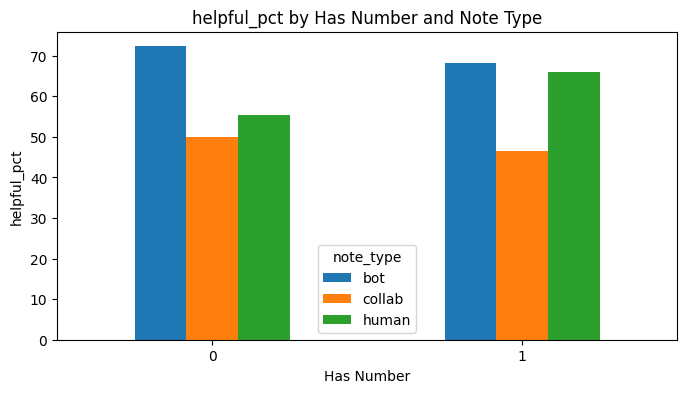

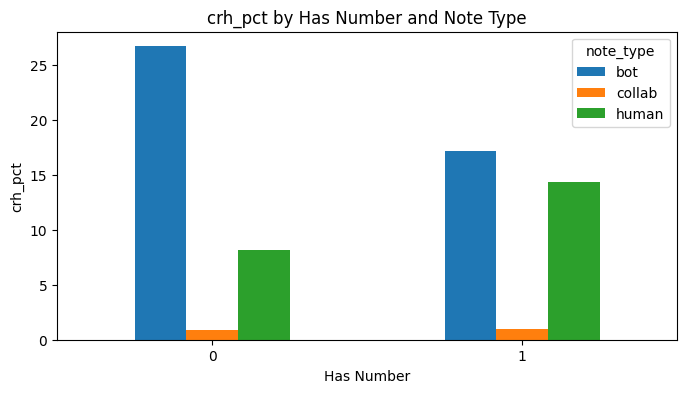

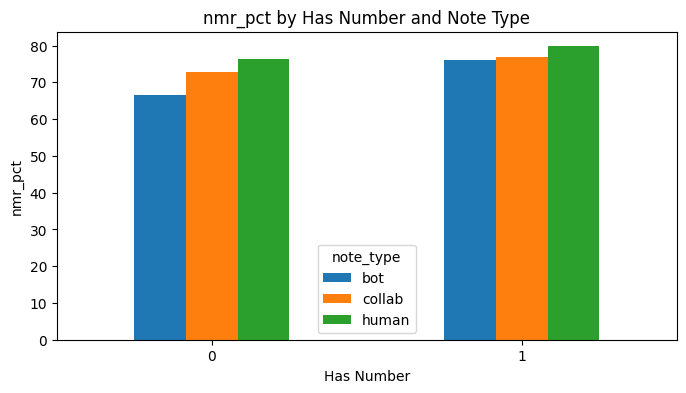

In [57]:
for metric in ["helpful_pct", "crh_pct", "nmr_pct"]:
    plot_df = number_summary.pivot(
        index="has_number",
        columns="note_type",
        values=metric
    ).fillna(0)

    plot_df.plot(kind="bar", figsize=(8,4))
    plt.title(f"{metric} by Has Number and Note Type")
    plt.xlabel("Has Number")
    plt.ylabel(metric)
    plt.xticks(rotation=0)
    plt.show()

In [58]:
analysis_notes["punct_bucket"] = pd.qcut(
    analysis_notes["punct_per_100_chars"],
    q=5,
    duplicates="drop"
)

In [59]:
punct_summary = (
    analysis_notes.groupby(["punct_bucket", "note_type"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        helpful_pct=("helpful_pct_strict", "mean"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean")
    )
    .reset_index()
)

for col in ["helpful_pct", "crh_pct", "nmr_pct"]:
    punct_summary[col] = punct_summary[col] * 100

display(punct_summary)

,punct_bucket,note_type,n_notes,helpful_pct,crh_pct,nmr_pct
0,"(-0.001, 2.54]",bot,105,68.823189,13.333333,80.952381
1,"(-0.001, 2.54]",collab,1950,45.663698,1.076923,74.820513
2,"(-0.001, 2.54]",human,432,62.608743,12.962963,78.009259
3,"(2.54, 2.932]",bot,82,65.963238,17.073171,79.268293
4,"(2.54, 2.932]",collab,2185,46.521089,1.006865,76.018307
5,"(2.54, 2.932]",human,218,64.368442,13.761468,79.357798
6,"(2.932, 3.311]",bot,77,67.856127,15.584416,76.623377
7,"(2.932, 3.311]",collab,2230,47.895508,0.941704,77.443946
8,"(2.932, 3.311]",human,181,63.932546,13.812155,79.558011
9,"(3.311, 3.795]",bot,58,72.001941,31.034483,65.517241


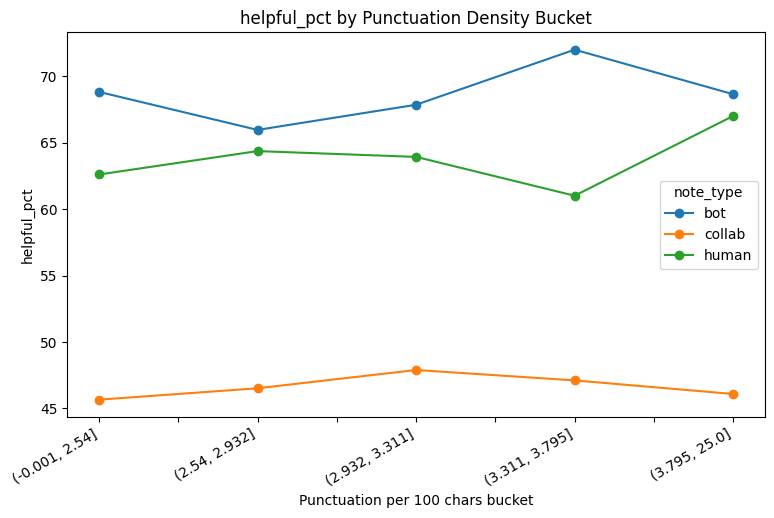

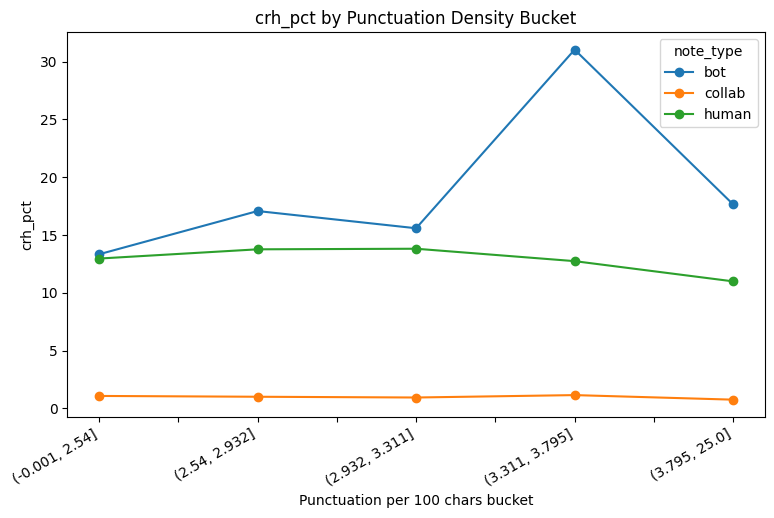

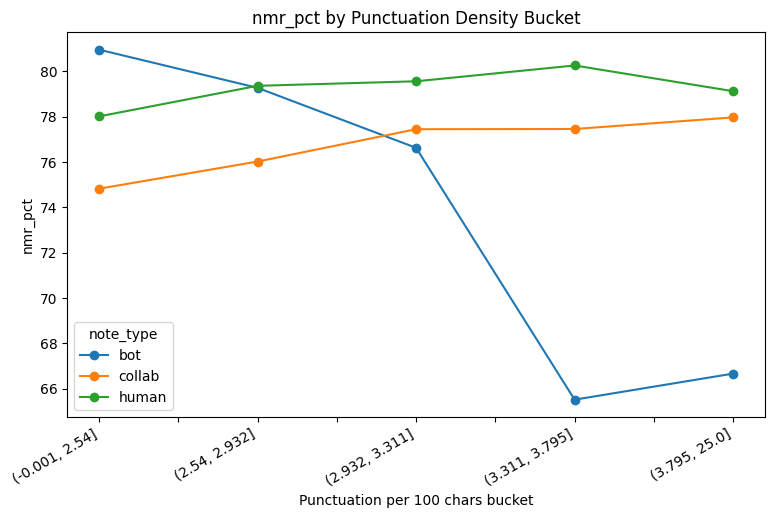

In [60]:
for metric in ["helpful_pct", "crh_pct", "nmr_pct"]:
    plot_df = punct_summary.pivot(
        index="punct_bucket",
        columns="note_type",
        values=metric
    )

    plot_df.plot(kind="line", marker="o", figsize=(9,5))
    plt.title(f"{metric} by Punctuation Density Bucket")
    plt.xlabel("Punctuation per 100 chars bucket")
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.show()

In [61]:
collab_only = analysis_notes[analysis_notes["note_type"] == "collab"].copy()

collab_only["len_bucket"] = pd.cut(
    collab_only["summary_len"],
    bins=[-0.1, 150, 250, 350, 500, np.inf],
    labels=["<=150", "151-250", "251-350", "351-500", "500+"]
)

collab_len_sent = (
    collab_only.groupby(["len_bucket", "sentence_bucket"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        helpful_pct=("helpful_pct_strict", "mean"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean")
    )
    .reset_index()
)

for col in ["helpful_pct", "crh_pct", "nmr_pct"]:
    collab_len_sent[col] = collab_len_sent[col] * 100

display(collab_len_sent.head(20))

,len_bucket,sentence_bucket,n_notes,helpful_pct,crh_pct,nmr_pct
0,<=150,1,0,NaN,NaN,NaN
1,<=150,2,0,NaN,NaN,NaN
2,<=150,3,1,100.000000,0.000000,100.000000
3,<=150,4-5,1,100.000000,0.000000,100.000000
4,<=150,6-10,0,NaN,NaN,NaN
5,<=150,10+,0,NaN,NaN,NaN
6,151-250,1,0,NaN,NaN,NaN
7,151-250,2,0,NaN,NaN,NaN
8,151-250,3,7,41.666667,0.000000,71.428571
9,151-250,4-5,193,43.594992,1.036269,70.466321


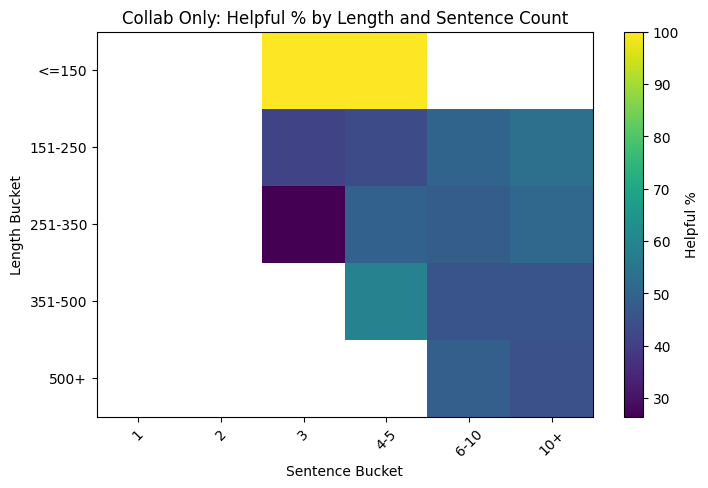

In [62]:
import matplotlib.pyplot as plt

heat = collab_len_sent.pivot(
    index="len_bucket",
    columns="sentence_bucket",
    values="helpful_pct"
)

plt.figure(figsize=(8,5))
plt.imshow(heat, aspect="auto")
plt.colorbar(label="Helpful %")
plt.xticks(range(len(heat.columns)), heat.columns, rotation=45)
plt.yticks(range(len(heat.index)), heat.index)
plt.title("Collab Only: Helpful % by Length and Sentence Count")
plt.xlabel("Sentence Bucket")
plt.ylabel("Length Bucket")
plt.show()

In [65]:
analysis_notes["url_count"] = analysis_notes["summary"].str.count(
    r"http|www\.|\.com|\.org|\.net",
    flags=re.IGNORECASE
)

In [69]:
analysis_notes["url_count_bucket"] = pd.cut(
    analysis_notes["url_count"],
    bins=[-0.1, 0, 1, 2, 3, 5, np.inf],
    labels=["0", "1", "2", "3", "4-5", "5+"]
)

In [70]:
url_count_summary = (
    analysis_notes.groupby(["url_count_bucket", "note_type"], observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        helpful_pct=("helpful_pct_strict", "mean"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean")
    )
    .reset_index()
)

for col in ["helpful_pct", "crh_pct", "nmr_pct"]:
    url_count_summary[col] = url_count_summary[col] * 100

display(url_count_summary)

,url_count_bucket,note_type,n_notes,helpful_pct,crh_pct,nmr_pct
0,0,bot,0,NaN,NaN,NaN
1,0,collab,0,NaN,NaN,NaN
2,0,human,145,49.849707,0.689655,77.241379
3,1,bot,4,75.555556,0.000000,75.000000
4,1,collab,100,30.152755,1.000000,68.000000
5,1,human,86,71.689584,17.441860,75.581395
6,2,bot,24,68.298882,16.666667,75.000000
7,2,collab,479,45.159128,1.252610,70.981211
8,2,human,400,63.577361,12.500000,79.750000
9,3,bot,44,63.288016,11.363636,84.090909


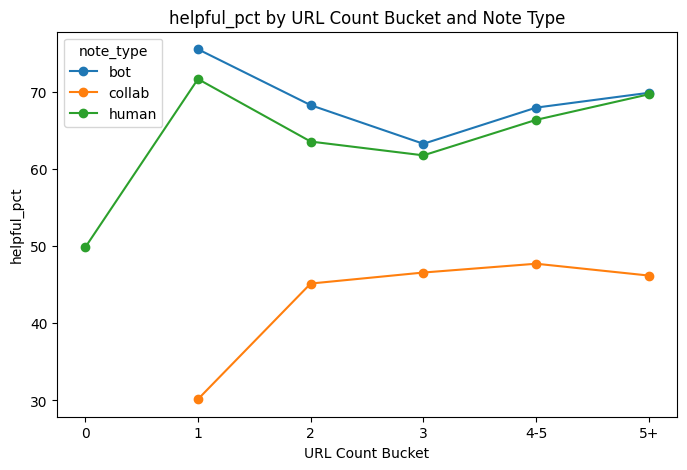

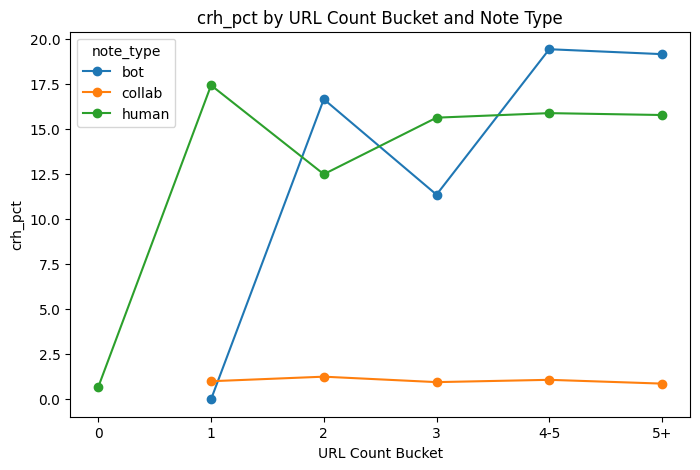

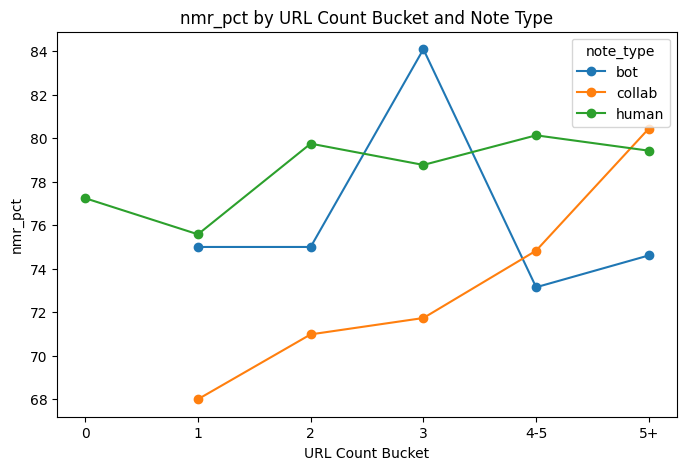

In [71]:
for metric in ["helpful_pct", "crh_pct", "nmr_pct"]:
    plot_df = url_count_summary.pivot(
        index="url_count_bucket",
        columns="note_type",
        values=metric
    ).sort_index()

    plot_df.plot(kind="line", marker="o", figsize=(8,5))
    plt.title(f"{metric} by URL Count Bucket and Note Type")
    plt.xlabel("URL Count Bucket")
    plt.ylabel(metric)
    plt.show()

In [72]:
collab_url_summary = (
    analysis_notes[analysis_notes["note_type"] == "collab"]
    .groupby("url_count_bucket", observed=False)
    .agg(
        n_notes=("noteId", "nunique"),
        helpful_pct=("helpful_pct_strict", "mean"),
        crh_pct=("is_crh", "mean"),
        nmr_pct=("is_nmr", "mean")
    )
    .reset_index()
)

for col in ["helpful_pct", "crh_pct", "nmr_pct"]:
    collab_url_summary[col] = collab_url_summary[col] * 100

display(collab_url_summary)

,url_count_bucket,n_notes,helpful_pct,crh_pct,nmr_pct
0,0,0,NaN,NaN,NaN
1,1,100,30.152755,1.000000,68.000000
2,2,479,45.159128,1.252610,70.981211
3,3,842,46.587758,0.950119,71.733967
4,4-5,4732,47.729613,1.077768,74.830938
5,5+,4725,46.194234,0.867725,80.444444


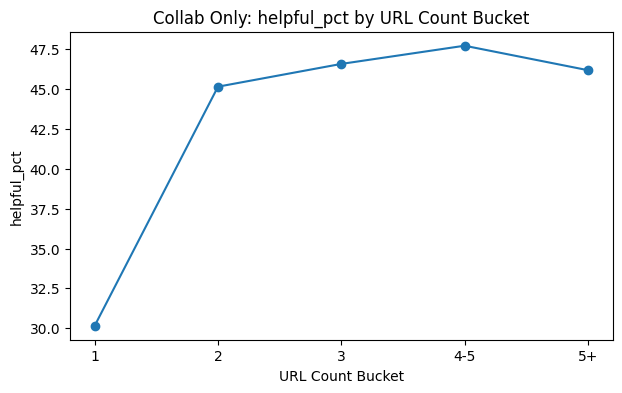

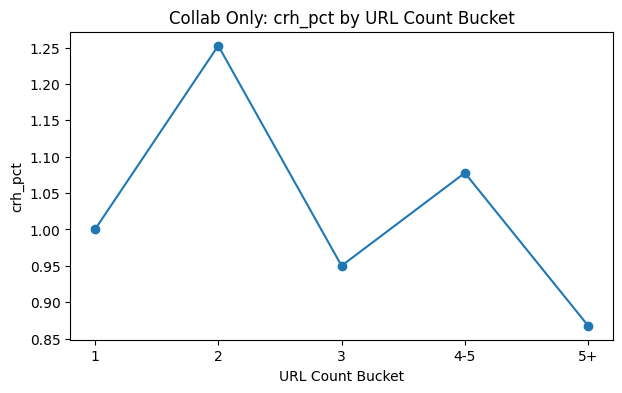

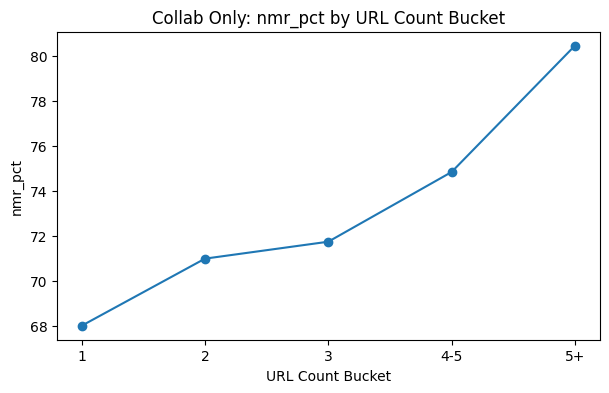

In [73]:
for metric in ["helpful_pct", "crh_pct", "nmr_pct"]:
    plt.figure(figsize=(7,4))
    plt.plot(
        collab_url_summary["url_count_bucket"].astype(str),
        collab_url_summary[metric],
        marker="o"
    )
    plt.title(f"Collab Only: {metric} by URL Count Bucket")
    plt.xlabel("URL Count Bucket")
    plt.ylabel(metric)
    plt.show()